# Hate Speech Detection in Social Media Using Machine Learning and Deep Learning

**Module:** MSc Artificial Intelligence and Data Science  
**Task:** Natural Language Processing (NLP) — Multi-class Text Classification  
**Dataset:** Davidson et al. (2017) — Automated Hate Speech Detection and the Problem of Offensive Language  
**Author:** Alake Akinlabi Ayomide  

---

## Table of Contents

1. [Environment Setup & Dependencies](#1-environment-setup--dependencies)
2. [Data Loading & Initial Exploration](#2-data-loading--initial-exploration)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
4. [Text Preprocessing Pipeline](#4-text-preprocessing-pipeline)
5. [Baseline Model](#5-baseline-model)
6. [Traditional ML — Naive Bayes](#6-traditional-ml--naive-bayes)
7. [Traditional ML — Support Vector Machine (SVM)](#7-traditional-ml--support-vector-machine-svm)
8. [Deep Learning — Bidirectional LSTM (BiLSTM)](#8-deep-learning--bidirectional-lstm-bilstm)
9. [Deep Learning — Fine-tuned DistilBERT](#9-deep-learning--fine-tuned-distilbert)
10. [Model Comparison & Final Evaluation](#10-model-comparison--final-evaluation)
11. [Conclusion](#11-conclusion)

---

## 1. Environment Setup & Dependencies

Install and import all required libraries. This project uses scikit-learn for traditional ML,
TensorFlow/Keras for the BiLSTM, and HuggingFace Transformers for DistilBERT fine-tuning.

In [1]:
# ============================================================
# 1.1 Install required packages (run once, then restart kernel)
# ============================================================
# Uncomment and run this cell ONCE if packages are missing:

import sys
!"{sys.executable}" -m pip install pandas numpy matplotlib seaborn scikit-learn wordcloud nltk
!"{sys.executable}" -m pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
!"{sys.executable}" -m pip install tensorflow transformers datasets
!"{sys.executable}" -m pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# 1.2 Import libraries
# ============================================================

# --- Core data handling ---
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# --- Text processing ---
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# --- Traditional ML ---
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, precision_recall_curve, average_precision_score,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier

# --- Class imbalance handling ---
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Deep Learning (BiLSTM — TensorFlow/Keras) ---
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout, 
    SpatialDropout1D, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# --- Transformer (DistilBERT — PyTorch) ---
import torch
from torch.utils.data import Dataset as TorchDataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizer, DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# --- NLTK data downloads ---
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# --- Reproducibility ---
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Device selection for PyTorch ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Plot styling ---
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

print("All libraries loaded successfully.")
print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch device: {device}")
print(f"GPU available (TF): {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"GPU available (PyTorch): {torch.cuda.is_available()}")

All libraries loaded successfully.
TensorFlow version: 2.20.0
PyTorch version: 2.11.0+cpu
PyTorch device: cpu
GPU available (TF): False
GPU available (PyTorch): False


## 2. Data Loading & Initial Exploration

The dataset is sourced from Davidson et al. (2017), containing 24,802 tweets annotated via CrowdFlower
into three classes:
- **0 — Hate Speech** 
- **1 — Offensive Language**
- **2 — Neither**

The dataset was collected using keywords from HateBase.org and each tweet was reviewed by at least
three annotators with a majority-vote labelling scheme (92% inter-annotator agreement).

**Download:** https://github.com/t-davidson/hate-speech-and-offensive-language/tree/master/data  
Place `labeled_data.csv` in the same directory as this notebook.

In [3]:
# ============================================================
# 2.1 Load the dataset
# ============================================================
# Read the CSV file containing 24,783 labelled tweets from Davidson et al. (2017).
# The dataset was collected using hate speech keywords from HateBase.org and
# each tweet was annotated by at least 3 CrowdFlower workers via majority vote.

df = pd.read_csv('labeled_data.csv')

# The original column 'class' holds the numeric label (0, 1, 2) and 'tweet' holds
# the raw text. We rename them for clarity throughout the notebook.
df.rename(columns={'class': 'label', 'tweet': 'text'}, inplace=True)

# Map numeric labels to human-readable names so outputs are easier to interpret.
# 0 = Hate Speech, 1 = Offensive Language, 2 = Neither
label_map = {0: 'Hate Speech', 1: 'Offensive', 2: 'Neither'}
df['label_name'] = df['label'].map(label_map)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (24783, 8)
Columns: ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'label', 'text', 'label_name']

First 5 rows:


,Unnamed: 0,count,hate_speech,offensive_language,neither,label,text,label_name
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,Neither
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive


In [4]:
# ============================================================
# 2.2 Basic dataset statistics
# ============================================================
# Check for data quality issues (missing values, duplicates) and examine
# the class distribution. Understanding the balance between classes is critical
# because imbalanced datasets cause models to favour the majority class.

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total samples:        {len(df):,}")
print(f"Total features:       {df.shape[1]}")
print(f"Missing values:       {df.isnull().sum().sum()}")
print(f"Duplicate tweets:     {df['text'].duplicated().sum()}")
print(f"\nClass distribution:")
print("-" * 40)

class_dist = df['label_name'].value_counts()
for cls, count in class_dist.items():
    pct = count / len(df) * 100
    print(f"  {cls:20s} {count:6,} ({pct:5.1f}%)")

# The imbalance ratio tells us how many times larger the biggest class is
# compared to the smallest. A ratio above 10x typically requires balancing techniques.
print(f"\nImbalance ratio (majority/minority): {class_dist.max() / class_dist.min():.1f}x")

DATASET OVERVIEW
Total samples:        24,783
Total features:       8
Missing values:       0
Duplicate tweets:     0

Class distribution:
----------------------------------------
  Offensive            19,190 ( 77.4%)
  Neither               4,163 ( 16.8%)
  Hate Speech           1,430 (  5.8%)

Imbalance ratio (majority/minority): 13.4x


In [5]:
# ============================================================
# 2.3 Data types and annotator agreement
# ============================================================
# Verify that columns have the expected types (int for numeric, object for text).
# The 'count' column shows how many annotators reviewed each tweet — higher counts
# indicate tweets where annotators initially disagreed and more reviewers were needed.

print("Data types:")
print(df.dtypes)
print(f"\nAnnotator count statistics (number of annotators per tweet):")
print(df['count'].describe().round(2))

Data types:
Unnamed: 0             int64
count                  int64
hate_speech            int64
offensive_language     int64
neither                int64
label                  int64
text                  object
label_name            object
dtype: object

Annotator count statistics (number of annotators per tweet):
count    24783.00
mean         3.24
std          0.88
min          3.00
25%          3.00
50%          3.00
75%          3.00
max          9.00
Name: count, dtype: float64


## 3. Exploratory Data Analysis (EDA)

This section explores the dataset to understand its properties, identify patterns, 
and inform preprocessing decisions. We examine class distribution, text characteristics, 
and generate visualisations including word clouds and frequency analyses.

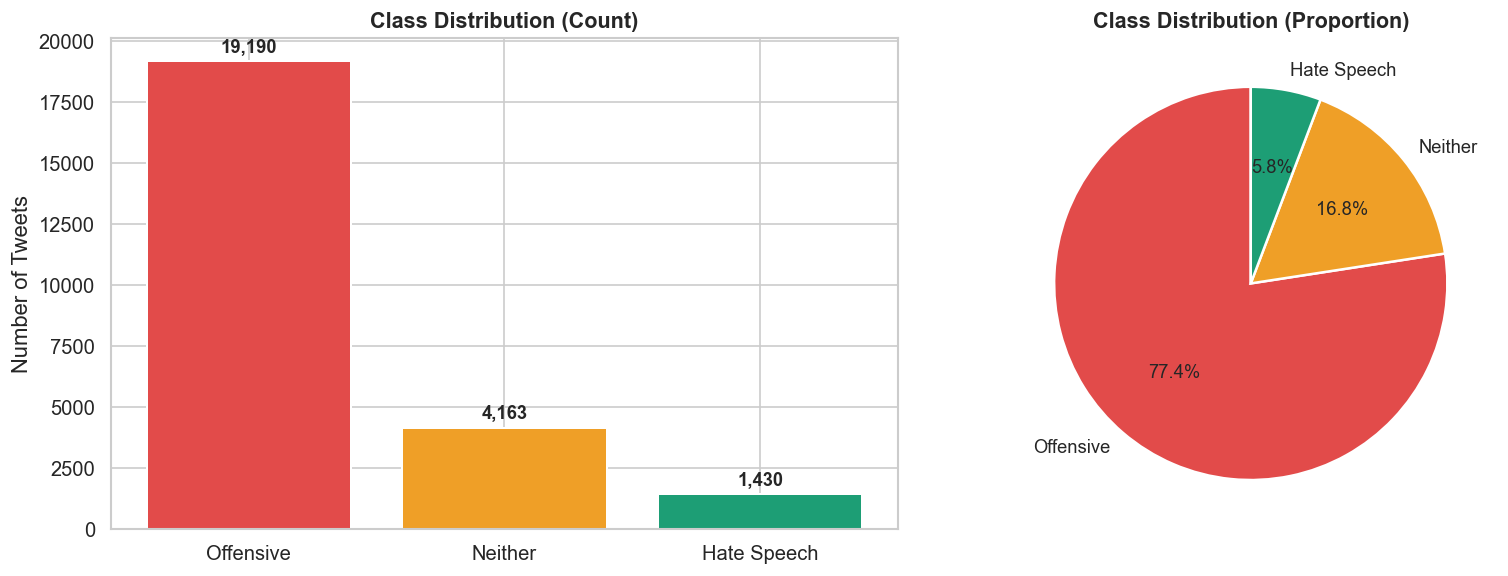


Key observation: Severe class imbalance — Offensive language dominates at 77.4%,
while Hate Speech accounts for only 5.8%. This will require class balancing strategies.


In [6]:
# ============================================================
# 3.1 Class distribution visualisation
# ============================================================
# Visualise the class imbalance using both a bar chart (for absolute counts)
# and a pie chart (for proportions). Two views of the same data help communicate
# both the scale difference and the dominance of the Offensive class.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define consistent colours: red=Hate Speech, amber=Offensive, green=Neither
colours = ['#E24B4A', '#EF9F27', '#1D9E75']
class_counts = df['label_name'].value_counts()

# Bar chart — shows raw counts so you can see the absolute gap between classes
bars = axes[0].bar(class_counts.index, class_counts.values, color=colours, edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Distribution (Count)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Tweets')

# Label each bar with its exact count for precision
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Pie chart — shows proportions so you can see Offensive takes up 3/4 of the data
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colours, startangle=90, textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution (Proportion)', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('fig_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey observation: Severe class imbalance — Offensive language dominates at 77.4%,")
print("while Hate Speech accounts for only 5.8%. This will require class balancing strategies.")

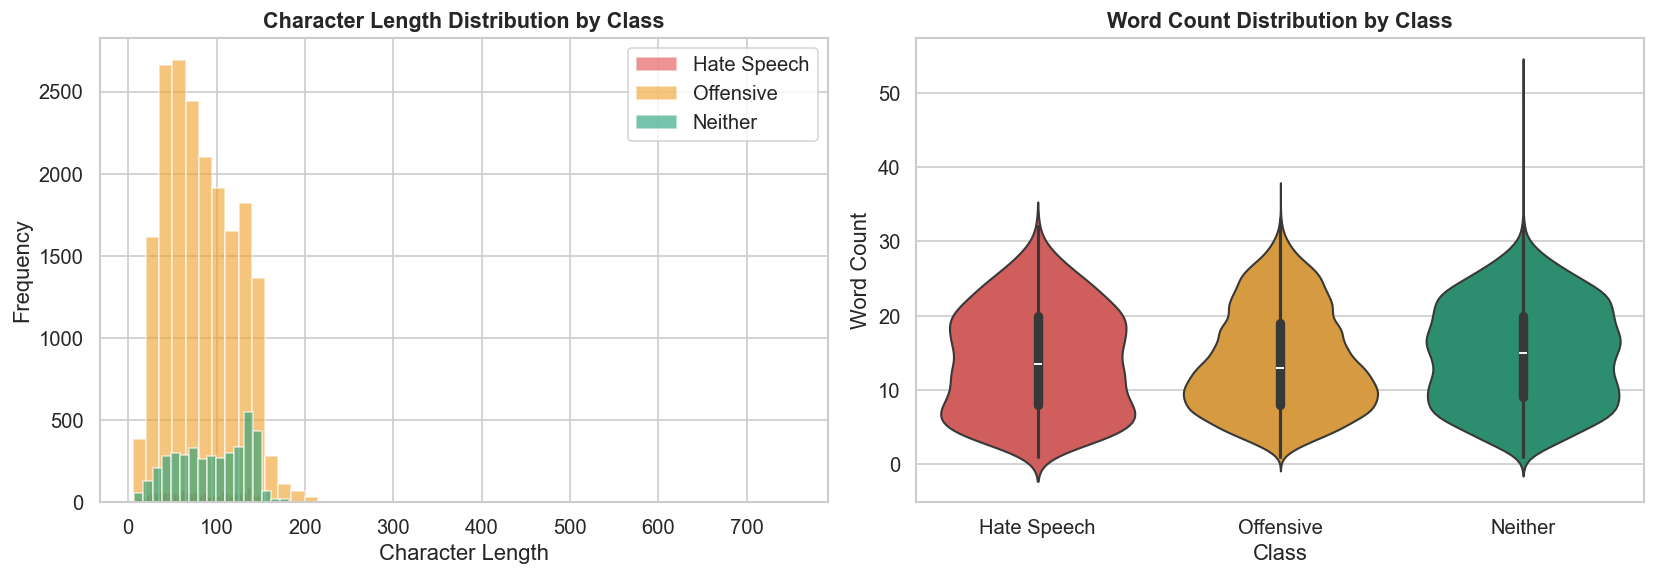


Text length statistics by class:
            text_length                                            word_count  \
                  count  mean   std  min   25%   50%    75%    max      count   
label_name                                                                      
Hate Speech      1430.0  84.6  40.5  5.0  49.0  82.0  121.0  254.0     1430.0   
Neither          4163.0  94.9  41.1  7.0  60.0  97.0  132.0  522.0     4163.0   
Offensive       19190.0  83.5  41.5  5.0  50.0  78.0  115.0  754.0    19190.0   

                                                    
             mean  std  min  25%   50%   75%   max  
label_name                                          
Hate Speech  13.9  7.0  1.0  8.0  13.5  20.0  32.0  
Neither      14.9  6.8  1.0  9.0  15.0  20.0  52.0  
Offensive    14.0  6.8  1.0  8.0  13.0  19.0  36.0  


In [7]:
# ============================================================
# 3.2 Text length analysis
# ============================================================
# Examine whether text length (in characters or words) differs across classes.
# If classes had very different lengths, length alone could be a useful feature.
# If they're similar, models must rely on actual word content to classify.

# Calculate two length features for each tweet
df['text_length'] = df['text'].apply(len)          # character count
df['word_count'] = df['text'].apply(lambda x: len(x.split()))  # word count

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — overlaid distributions show if one class tends to be longer/shorter
for label, colour in zip([0, 1, 2], colours):
    subset = df[df['label'] == label]['text_length']
    axes[0].hist(subset, bins=50, alpha=0.6, label=label_map[label], color=colour, edgecolor='white')

axes[0].set_title('Character Length Distribution by Class', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Violin plot — shows the full shape of each distribution including median and quartiles
sns.violinplot(data=df, x='label_name', y='word_count', palette=colours, ax=axes[1],
               order=['Hate Speech', 'Offensive', 'Neither'])
axes[1].set_title('Word Count Distribution by Class', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('fig_text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics grouped by class to confirm visual observations
print("\nText length statistics by class:")
print(df.groupby('label_name')[['text_length', 'word_count']].describe().round(1))

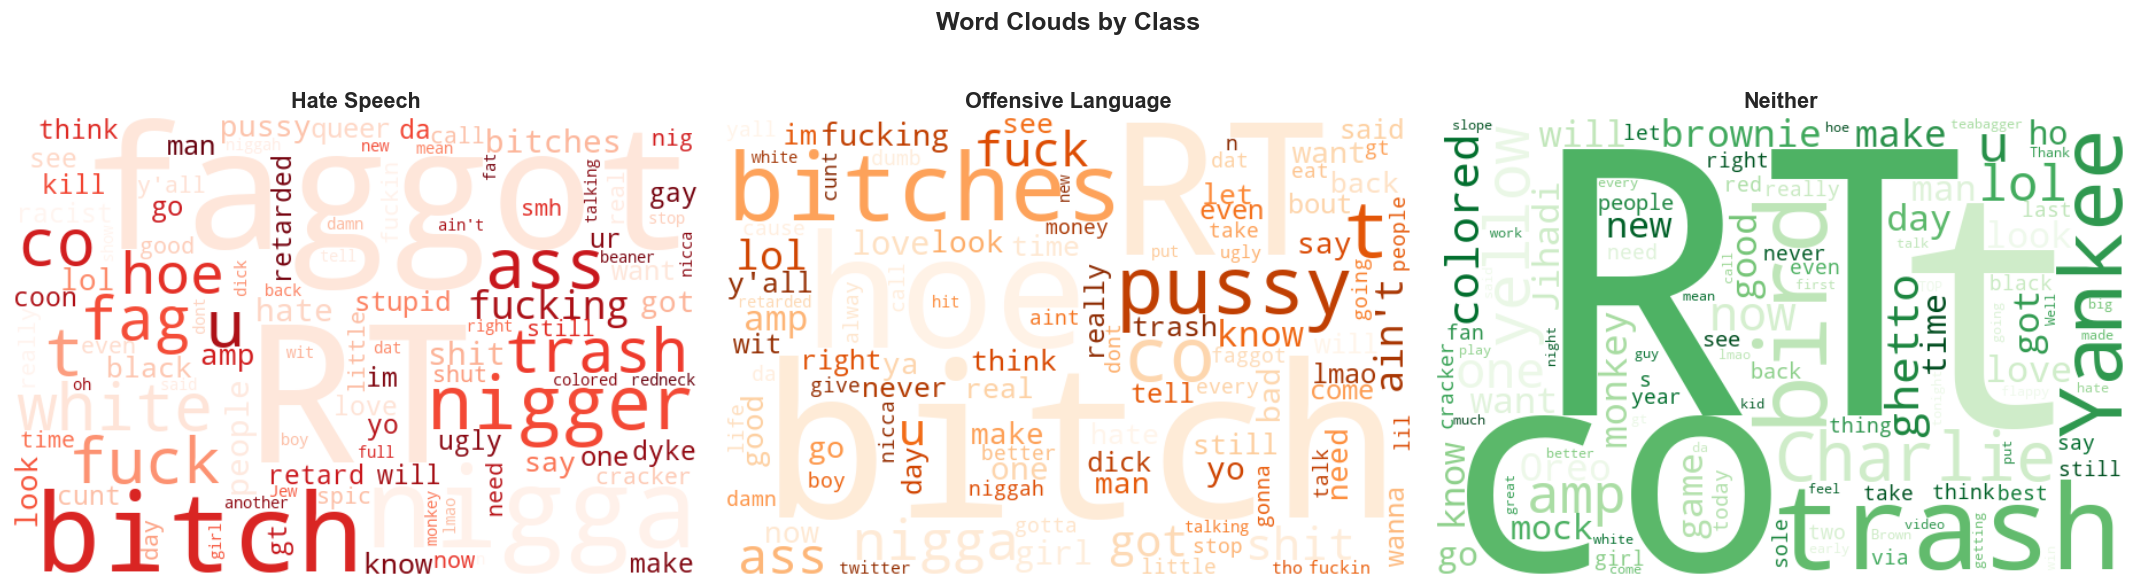

In [8]:
# ============================================================
# 3.3 Word clouds per class
# ============================================================
# Word clouds display the most frequent words in each class, with word size
# proportional to frequency. This reveals the vocabulary that characterises
# each class and highlights overlap between Hate Speech and Offensive Language.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (label, title, colour) in enumerate(zip(
    [0, 1, 2],
    ['Hate Speech', 'Offensive Language', 'Neither'],
    ['Reds', 'Oranges', 'Greens']
)):
    # Concatenate all tweets of this class into one string for the word cloud
    text = ' '.join(df[df['label'] == label]['text'].values)
    wc = WordCloud(
        width=600, height=400, max_words=100,
        background_color='white', colormap=colour,
        random_state=SEED, collocations=False  # collocations=False avoids repeating bigrams
    ).generate(text)
    
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(title, fontweight='bold', fontsize=13)
    axes[idx].axis('off')

plt.suptitle('Word Clouds by Class', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('fig_word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()

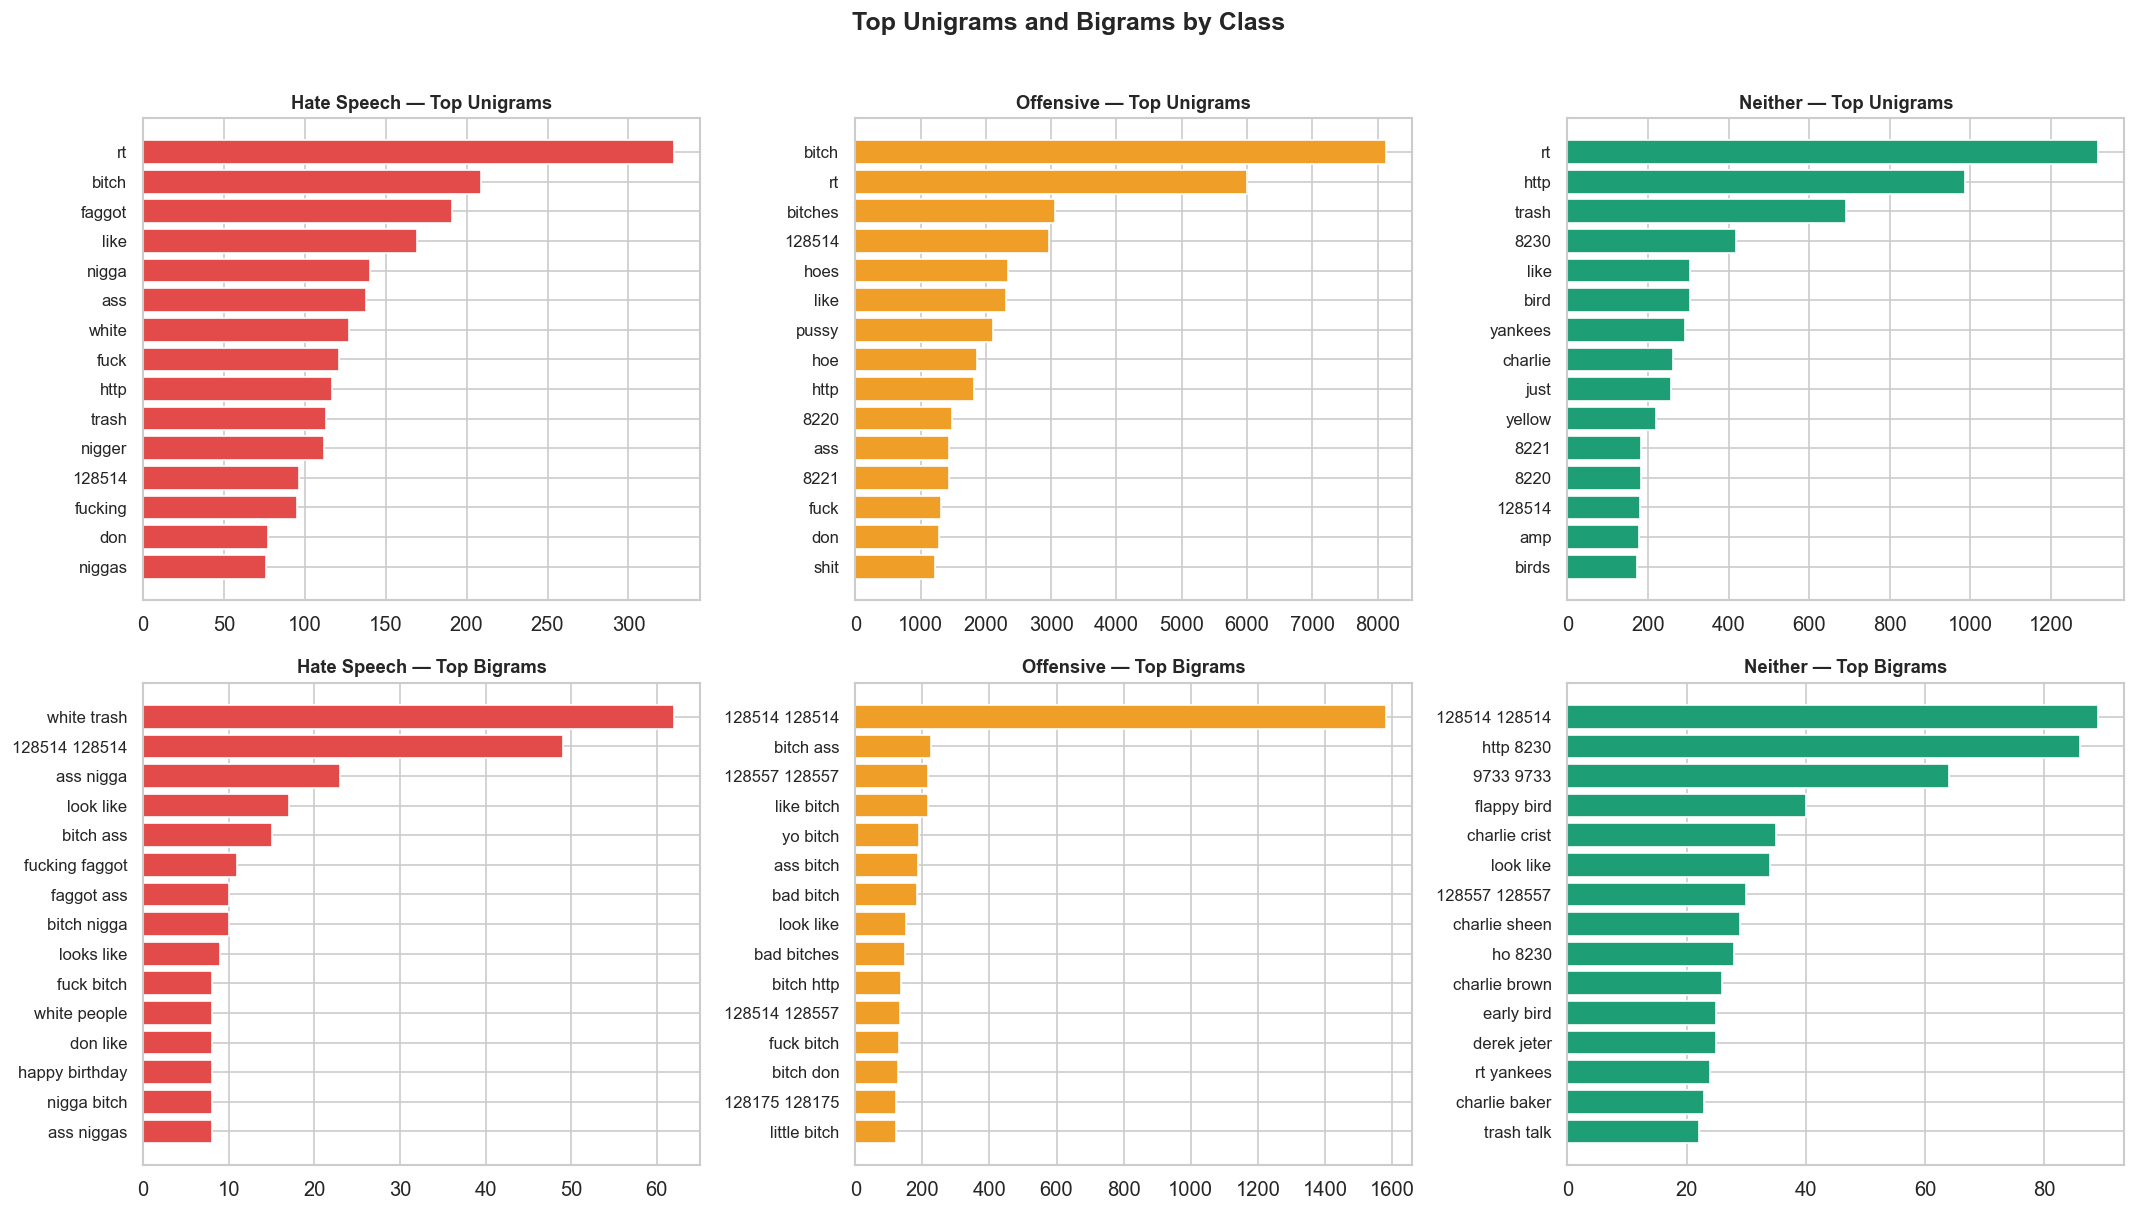

In [9]:
# ============================================================
# 3.4 Top N-grams analysis (unigrams and bigrams)
# ============================================================
# N-grams are contiguous sequences of n words. Unigrams = single words, bigrams = word pairs.
# Analysing bigrams is important because some hate speech expressions are multi-word
# (e.g. compound slurs) that would be missed by looking at individual words alone.

from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=20, ngram_range=(1,1)):
    """Extract the top n most frequent n-grams from a text corpus."""
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=n)
    bag = vec.fit_transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (label, title) in enumerate(zip([0, 1, 2], ['Hate Speech', 'Offensive', 'Neither'])):
    subset = df[df['label'] == label]['text'].values
    
    # Top row: unigrams (single words) — shows the dominant vocabulary per class
    top_uni = get_top_ngrams(subset, n=15, ngram_range=(1,1))
    words, counts = zip(*top_uni)
    axes[0, col].barh(range(len(words)), counts, color=colours[col], edgecolor='white')
    axes[0, col].set_yticks(range(len(words)))
    axes[0, col].set_yticklabels(words, fontsize=10)
    axes[0, col].invert_yaxis()
    axes[0, col].set_title(f'{title} — Top Unigrams', fontweight='bold', fontsize=11)
    
    # Bottom row: bigrams (word pairs) — captures multi-word expressions and compound slurs
    top_bi = get_top_ngrams(subset, n=15, ngram_range=(2,2))
    words, counts = zip(*top_bi)
    axes[1, col].barh(range(len(words)), counts, color=colours[col], edgecolor='white')
    axes[1, col].set_yticks(range(len(words)))
    axes[1, col].set_yticklabels(words, fontsize=10)
    axes[1, col].invert_yaxis()
    axes[1, col].set_title(f'{title} — Top Bigrams', fontweight='bold', fontsize=11)

plt.suptitle('Top Unigrams and Bigrams by Class', fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('fig_ngram_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Text Preprocessing Pipeline

Social media text requires extensive cleaning. Our preprocessing pipeline handles:
1. Lowercasing
2. URL removal
3. Mention (@user) removal  
4. Hashtag cleaning (remove # symbol, keep text)
5. RT (retweet) prefix removal
6. HTML entity decoding
7. Punctuation and special character removal
8. Number removal
9. Stopword removal
10. Lemmatisation

We apply this consistently across all models to ensure fair comparison.

In [10]:
# ============================================================
# 4.1 Define preprocessing functions
# ============================================================
# Social media text is messy — full of URLs, @mentions, hashtags, emojis, slang,
# and inconsistent formatting. This pipeline standardises everything so models
# focus on meaningful content words rather than noise.
# Each step addresses a specific noise source common in Twitter data.

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Comprehensive text cleaning pipeline for social media (Twitter) data.
    
    Parameters
    ----------
    text : str
        Raw tweet text.
    
    Returns
    -------
    str
        Cleaned and normalised text.
    """
    text = text.lower()                                          # Standardise case
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r'@\w+', '', text)                            # Remove @mentions (usernames)
    text = re.sub(r'^rt\s+', '', text)                          # Remove RT (retweet) prefix
    text = re.sub(r'#', '', text)                                # Remove # but keep hashtag text
    text = re.sub(r'&[a-zA-Z]+;', '', text)                     # Remove HTML entities (&amp; etc.)
    text = re.sub(r'\d+', '', text)                              # Remove numbers (incl. Unicode codes)
    text = re.sub(r'[^\w\s]', '', text)                         # Remove punctuation & special chars
    text = re.sub(r'\s+', ' ', text).strip()                    # Collapse multiple spaces
    
    # Tokenise into individual words, remove common stopwords (the, is, at, etc.)
    # and lemmatise (converts words to base form: "running" -> "run", "better" -> "good")
    # Only keep tokens with 3+ characters to remove fragments like "rt", "co"
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    
    return ' '.join(tokens)

# Apply the cleaning function to every tweet in the dataset
print("Applying text preprocessing pipeline...")
df['clean_text'] = df['text'].apply(clean_text)

# Show before/after examples so we can verify the pipeline works correctly
print("\nPreprocessing examples:")
print("=" * 80)
for i in range(3):
    print(f"ORIGINAL:  {df['text'].iloc[i][:100]}...")
    print(f"CLEANED:   {df['clean_text'].iloc[i][:100]}")
    print("-" * 80)

# Check if any tweets became empty after cleaning (e.g. tweets that were only URLs/mentions)
empty_count = (df['clean_text'].str.strip() == '').sum()
print(f"\nEmpty strings after cleaning: {empty_count}")

# Remove empty rows since models can't learn from blank text
if empty_count > 0:
    df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
    print(f"Removed {empty_count} empty rows. New shape: {df.shape}")

Applying text preprocessing pipeline...

Preprocessing examples:
ORIGINAL:  !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man...
CLEANED:   woman shouldnt complain cleaning house man always take trash
--------------------------------------------------------------------------------
ORIGINAL:  !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!...
CLEANED:   boy dat coldtyga dwn bad cuffin dat hoe place
--------------------------------------------------------------------------------
ORIGINAL:  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You...
CLEANED:   dawg ever fuck bitch start cry confused shit
--------------------------------------------------------------------------------

Empty strings after cleaning: 3
Removed 3 empty rows. New shape: (24780, 11)


In [11]:
# ============================================================
# 4.2 Train-test split (stratified)
# ============================================================
# Split data into 80% training and 20% testing.
# 'stratify=y' ensures both sets maintain the same class proportions (5.8% / 77.4% / 16.8%).
# Without stratification, the small Hate Speech class might be underrepresented in one set.

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts().sort_index().apply(lambda x: f"{x:,} ({x/len(y_train)*100:.1f}%)"))
print(f"\nTest class distribution:")
print(y_test.value_counts().sort_index().apply(lambda x: f"{x:,} ({x/len(y_test)*100:.1f}%)"))

Training set: 19,824 samples
Test set:     4,956 samples

Training class distribution:
label
0      1,144 (5.8%)
1    15,351 (77.4%)
2     3,329 (16.8%)
Name: count, dtype: object

Test class distribution:
label
0       286 (5.8%)
1    3,838 (77.4%)
2      832 (16.8%)
Name: count, dtype: object


In [12]:
# ============================================================
# 4.3 TF-IDF vectorisation (for traditional ML models)
# ============================================================
# TF-IDF converts text into numerical vectors that ML models can process.
# TF (Term Frequency): how often a word appears in a document
# IDF (Inverse Document Frequency): penalises words that appear in many documents
# Result: common words like "the" get low scores, distinctive words get high scores.
#
# Configuration choices:
# - max_features=15000: keep only the 15K most informative terms (reduces noise)
# - ngram_range=(1,2): include both single words AND word pairs (catches compound slurs)
# - sublinear_tf=True: use log(1+TF) so very frequent words don't dominate
# - min_df=2: ignore words appearing in only 1 document (likely typos or noise)
# - max_df=0.95: ignore words appearing in 95%+ of documents (too common to be useful)

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    strip_accents='unicode'
)

# fit_transform on training data: learns the vocabulary AND transforms the text
# transform on test data: uses the SAME vocabulary (no data leakage from test set)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test):  {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_):,} features")

TF-IDF matrix shape (train): (19824, 15000)
TF-IDF matrix shape (test):  (4956, 15000)
Vocabulary size: 15,000 features


In [13]:
# ============================================================
# 4.4 Handle class imbalance with SMOTE
# ============================================================
# SMOTE (Synthetic Minority Over-sampling Technique) addresses class imbalance
# by generating synthetic samples for minority classes. It works by:
# 1. Picking a sample from the minority class
# 2. Finding its k nearest neighbours (k=5)
# 3. Creating a new synthetic sample along the line between them
#
# After SMOTE, all classes have equal counts in the training set.
# IMPORTANT: Only applied to TRAINING data — test set stays untouched
# so evaluation reflects the real-world imbalanced distribution.

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_tfidf_bal, y_train_bal = smote.fit_resample(X_train_tfidf, y_train)

print("Class distribution BEFORE SMOTE:")
print(pd.Series(y_train).value_counts().sort_index().to_string())
print(f"\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_bal).value_counts().sort_index().to_string())
print(f"\nTraining samples increased from {X_train_tfidf.shape[0]:,} to {X_train_tfidf_bal.shape[0]:,}")

Class distribution BEFORE SMOTE:
label
0     1144
1    15351
2     3329

Class distribution AFTER SMOTE:
label
0    15351
1    15351
2    15351

Training samples increased from 19,824 to 46,053


## 5. Baseline Model

Before building sophisticated models, we establish a baseline using a majority-class classifier.
This predicts the most frequent class (Offensive Language) for every sample, providing a lower
bound that all subsequent models must exceed.

In [14]:
# ============================================================
# 5.1 Majority class baseline
# ============================================================
# Before building complex models, establish a baseline: a "model" that simply
# predicts the most frequent class (Offensive) for every tweet.
# This gives us a lower bound — if our real models can't beat this, they're useless.
# The baseline will have high accuracy (~77%) but terrible Macro F1 because
# it completely ignores Hate Speech and Neither classes.

baseline = DummyClassifier(strategy='most_frequent', random_state=SEED)
baseline.fit(X_train_tfidf, y_train)
y_pred_base = baseline.predict(X_test_tfidf)

print("BASELINE MODEL — Majority Class Classifier")
print("=" * 60)
print(f"Baseline predicts class: {baseline.classes_[0]} ({label_map[baseline.classes_[0]]}) for all samples")
print(f"\nAccuracy:       {baseline.score(X_test_tfidf, y_test):.4f}")
print(f"Macro F1-score: {f1_score(y_test, y_pred_base, average='macro'):.4f}")
print(f"Weighted F1:    {f1_score(y_test, y_pred_base, average='weighted'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=list(label_map.values())))

BASELINE MODEL — Majority Class Classifier
Baseline predicts class: 0 (Hate Speech) for all samples

Accuracy:       0.7744
Macro F1-score: 0.2910
Weighted F1:    0.6760

Classification Report:
              precision    recall  f1-score   support

 Hate Speech       0.00      0.00      0.00       286
   Offensive       0.77      1.00      0.87      3838
     Neither       0.00      0.00      0.00       832

    accuracy                           0.77      4956
   macro avg       0.26      0.33      0.29      4956
weighted avg       0.60      0.77      0.68      4956



## 6. Traditional ML — Naive Bayes

Naive Bayes is a probabilistic classifier based on Bayes' theorem with strong independence 
assumptions between features. Despite its simplicity, it performs remarkably well on text 
classification tasks due to the high-dimensional, sparse nature of TF-IDF features.

We use **Complement Naive Bayes (CNB)**, which is specifically designed for imbalanced datasets
and typically outperforms Multinomial NB on text classification (Rennie et al., 2003).

In [15]:
# ============================================================
# 6.1 Complement Naive Bayes with hyperparameter tuning
# ============================================================
# Naive Bayes is a probabilistic classifier that assumes features are independent.
# We use Complement NB (not standard Multinomial NB) because it's specifically
# designed for imbalanced datasets — it estimates parameters using data from the
# COMPLEMENT of each class, reducing bias towards the majority class.
#
# Hyperparameter tuning via GridSearchCV:
# - alpha: smoothing parameter that prevents zero probabilities for unseen words
#   (too low = overfitting to training data; too high = too much smoothing)
# - We search 7 values and pick the one with the best cross-validated Macro F1

param_grid_nb = {
    'alpha': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
}

# 5-fold stratified cross-validation: splits training data into 5 parts,
# trains on 4 and validates on 1, rotates 5 times. Stratified ensures each
# fold maintains the class proportions.
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

nb_grid = GridSearchCV(
    ComplementNB(),
    param_grid_nb,
    cv=cv_strategy,
    scoring='f1_macro',  # optimise for Macro F1 (treats all classes equally)
    n_jobs=-1,           # use all CPU cores for parallel computation
    verbose=1
)

# Train on the SMOTE-balanced data so the model sees equal examples of all classes
nb_grid.fit(X_train_tfidf_bal, y_train_bal)

print(f"\nBest alpha: {nb_grid.best_params_['alpha']}")
print(f"Best CV macro F1: {nb_grid.best_score_:.4f}")

# Store the best model for later evaluation
nb_model = nb_grid.best_estimator_

Fitting 5 folds for each of 7 candidates, totalling 35 fits

Best alpha: 0.01
Best CV macro F1: 0.9208


In [16]:
# ============================================================
# 6.2 Naive Bayes — Evaluation on test set
# ============================================================
# Evaluate the tuned Naive Bayes model on the UNSEEN test set.
# We compute predictions and probability estimates (needed for ROC/PR curves later).
# The classification report breaks down precision, recall, and F1 per class.

y_pred_nb = nb_model.predict(X_test_tfidf)

# Probability estimates: for each tweet, the model outputs a probability for each class
# e.g. [0.1, 0.8, 0.1] means 10% hate speech, 80% offensive, 10% neither
y_prob_nb = nb_model.predict_proba(X_test_tfidf)

print("NAIVE BAYES (Complement NB) — Test Set Results")
print("=" * 60)
print(f"Accuracy:       {nb_model.score(X_test_tfidf, y_test):.4f}")
print(f"Macro F1-score: {f1_score(y_test, y_pred_nb, average='macro'):.4f}")
print(f"Weighted F1:    {f1_score(y_test, y_pred_nb, average='weighted'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=list(label_map.values())))

NAIVE BAYES (Complement NB) — Test Set Results
Accuracy:       0.7879
Macro F1-score: 0.6224
Weighted F1:    0.8038

Classification Report:
              precision    recall  f1-score   support

 Hate Speech       0.25      0.47      0.33       286
   Offensive       0.91      0.83      0.87      3838
     Neither       0.63      0.72      0.67       832

    accuracy                           0.79      4956
   macro avg       0.60      0.67      0.62      4956
weighted avg       0.83      0.79      0.80      4956



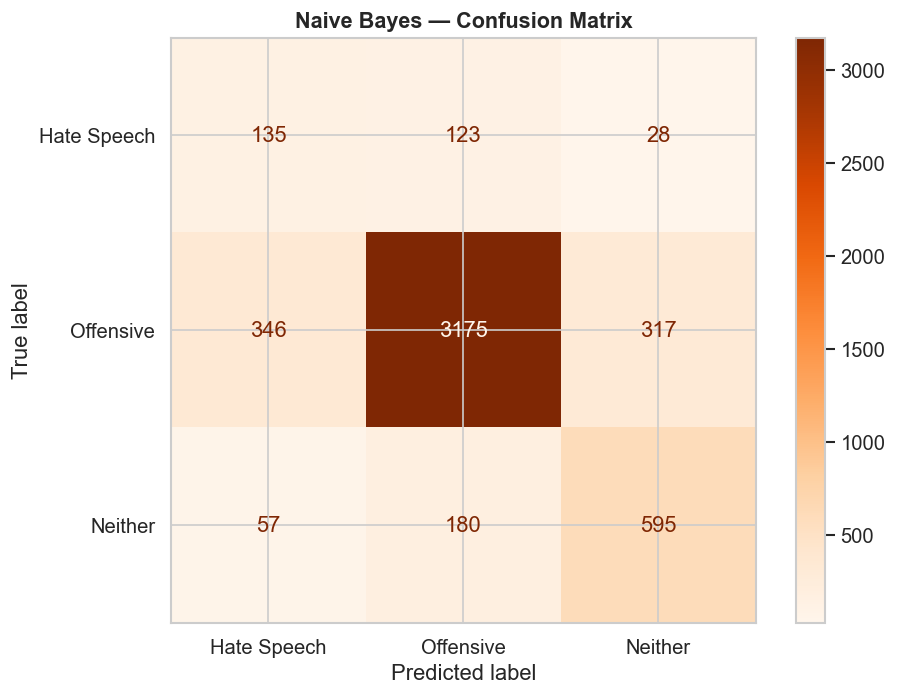

In [17]:
# ============================================================
# 6.3 Naive Bayes — Confusion matrix
# ============================================================
# A confusion matrix shows where the model gets confused between classes.
# Rows = actual class, Columns = predicted class.
# Diagonal values = correct predictions; off-diagonal = misclassifications.
# We expect the most confusion between Hate Speech and Offensive (they overlap).

fig, ax = plt.subplots(figsize=(8, 6))
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(cm_nb, display_labels=list(label_map.values()))
disp.plot(ax=ax, cmap='Oranges', values_format='d')
ax.set_title('Naive Bayes — Confusion Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_nb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Traditional ML — Support Vector Machine (SVM)

Support Vector Machines find the optimal hyperplane that maximises the margin between classes.
For text classification, **Linear SVM** is particularly effective due to the high-dimensional 
nature of TF-IDF features (Joachims, 1998). We use `LinearSVC` wrapped in `CalibratedClassifierCV`
to obtain probability estimates needed for ROC-AUC computation.

In [18]:
# ============================================================
# 7.1 Linear SVM with hyperparameter tuning
# ============================================================
# SVM finds the hyperplane that best separates classes with maximum margin.
# Linear SVM works well for text because TF-IDF features are high-dimensional
# and often linearly separable — you don't need complex non-linear kernels.
#
# Hyperparameter C controls the trade-off between:
# - Low C: wider margin, more misclassifications allowed (underfitting risk)
# - High C: narrower margin, fewer misclassifications (overfitting risk)
# class_weight='balanced' adjusts weights inversely proportional to class frequency.

param_grid_svm = {
    'C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'max_iter': [5000]  # ensure convergence with enough iterations
}

svm_grid = GridSearchCV(
    LinearSVC(random_state=SEED, class_weight='balanced'),
    param_grid_svm,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_tfidf_bal, y_train_bal)

print(f"\nBest C: {svm_grid.best_params_['C']}")
print(f"Best CV macro F1: {svm_grid.best_score_:.4f}")

# LinearSVC doesn't natively output probabilities, so we wrap it in
# CalibratedClassifierCV which fits a calibration model (Platt scaling)
# to convert decision function scores into probability estimates.
svm_calibrated = CalibratedClassifierCV(svm_grid.best_estimator_, cv=3)
svm_calibrated.fit(X_train_tfidf_bal, y_train_bal)

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best C: 10.0
Best CV macro F1: 0.9443


CalibratedClassifierCV(cv=3,
                       estimator=LinearSVC(C=10.0, class_weight='balanced',
                                           max_iter=5000, random_state=42))

In [19]:
# ============================================================
# 7.2 SVM — Evaluation on test set
# ============================================================
# Evaluate the tuned SVM on unseen test data and extract probability estimates
# from the calibrated model for ROC/PR curve computation.

y_pred_svm = svm_calibrated.predict(X_test_tfidf)
y_prob_svm = svm_calibrated.predict_proba(X_test_tfidf)

print("SUPPORT VECTOR MACHINE (Linear SVM) — Test Set Results")
print("=" * 60)
print(f"Macro F1-score: {f1_score(y_test, y_pred_svm, average='macro'):.4f}")
print(f"Weighted F1:    {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=list(label_map.values())))

SUPPORT VECTOR MACHINE (Linear SVM) — Test Set Results
Macro F1-score: 0.6785
Weighted F1:    0.8623

Classification Report:
              precision    recall  f1-score   support

 Hate Speech       0.28      0.36      0.31       286
   Offensive       0.92      0.91      0.92      3838
     Neither       0.84      0.78      0.81       832

    accuracy                           0.86      4956
   macro avg       0.68      0.68      0.68      4956
weighted avg       0.87      0.86      0.86      4956



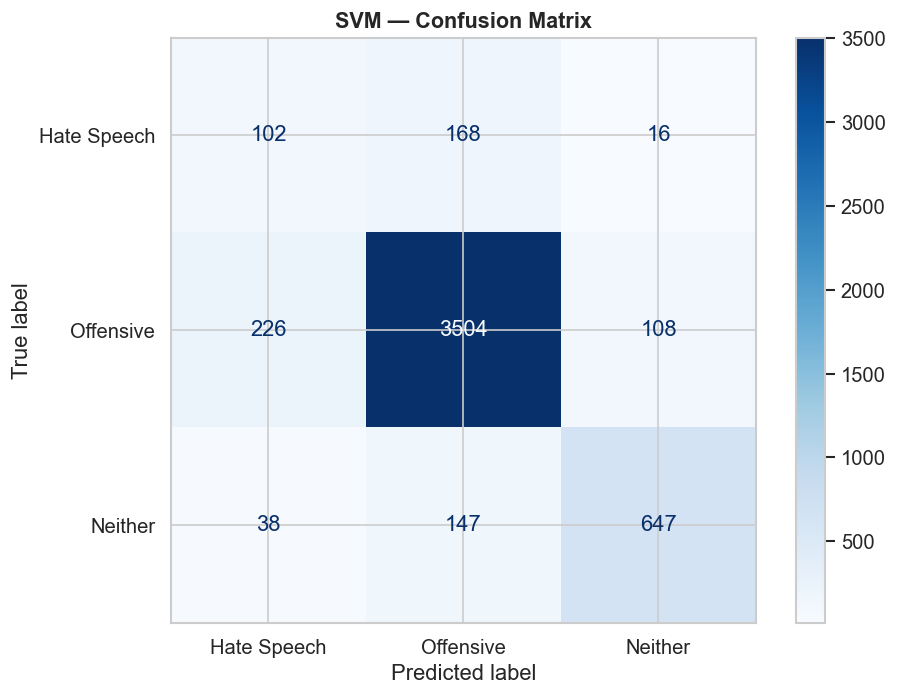

In [20]:
# ============================================================
# 7.3 SVM — Confusion matrix
# ============================================================
# Compare this to the NB confusion matrix — SVM should show fewer
# misclassifications, especially for the Hate Speech class.

fig, ax = plt.subplots(figsize=(8, 6))
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(cm_svm, display_labels=list(label_map.values()))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('SVM — Confusion Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Deep Learning — Bidirectional LSTM (BiLSTM)

Long Short-Term Memory (LSTM) networks are a type of recurrent neural network (RNN) capable of
learning long-term dependencies in sequential data. The **Bidirectional** variant processes text
in both forward and backward directions, capturing richer contextual information.

**Architecture:**
- Embedding layer (128 dimensions)
- SpatialDropout1D (0.3)
- Bidirectional LSTM (128 units)
- GlobalMaxPooling1D
- Dense layers with dropout
- Softmax output (3 classes)

**Refinement strategies:**
- Early stopping to prevent overfitting
- Learning rate reduction on plateau
- Class weights to handle imbalance
- Spatial dropout for regularisation

In [21]:
# ============================================================
# 8.1 Prepare sequences for BiLSTM
# ============================================================
# Unlike TF-IDF (which treats text as a bag of words ignoring order),
# LSTMs process text as a SEQUENCE — word order matters.
# Steps:
# 1. Tokenizer: assigns a unique integer ID to each word (e.g. "hate"->42, "speech"->107)
# 2. texts_to_sequences: converts each tweet into a list of integer IDs
# 3. pad_sequences: pads/truncates all sequences to the same length (100 tokens)
#    so they can be processed in batches by the neural network

MAX_WORDS = 20000    # Only keep the 20K most frequent words
MAX_LEN = 100        # Pad/truncate all tweets to 100 tokens (sufficient for tweets)

tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')  # OOV = out-of-vocabulary
tokenizer_lstm.fit_on_texts(X_train)  # Build vocabulary from training data only

# Convert text to integer sequences
X_train_seq = tokenizer_lstm.texts_to_sequences(X_train)
X_test_seq = tokenizer_lstm.texts_to_sequences(X_test)

# Pad shorter sequences with zeros and truncate longer ones
# 'post' padding: zeros added at the END (preserves the actual text at the start)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# One-hot encode labels for categorical crossentropy loss
# e.g. label 0 -> [1, 0, 0], label 1 -> [0, 1, 0], label 2 -> [0, 0, 1]
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

# Compute class weights: gives higher weight to minority classes during training
# so the model pays more attention to Hate Speech despite having fewer examples
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train.values)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}

print(f"Vocabulary size: {min(MAX_WORDS, len(tokenizer_lstm.word_index)):,}")
print(f"Sequence length: {MAX_LEN}")
print(f"Training sequences shape: {X_train_pad.shape}")
print(f"Test sequences shape:     {X_test_pad.shape}")
print(f"\nClass weights: { {label_map[k]: round(v, 3) for k, v in class_weights.items()} }")

Vocabulary size: 16,906
Sequence length: 100
Training sequences shape: (19824, 100)
Test sequences shape:     (4956, 100)

Class weights: {'Hate Speech': np.float64(5.776), 'Offensive': np.float64(0.43), 'Neither': np.float64(1.985)}


In [22]:
# ============================================================
# 8.2 Build BiLSTM model
# ============================================================
# Architecture explained layer by layer:
# 1. Embedding: converts word IDs into dense vectors (128-dim) — learns word relationships
# 2. SpatialDropout1D: randomly drops entire embedding channels (regularisation for text)
# 3. Bidirectional LSTM: processes sequence forwards AND backwards, capturing context
#    from both directions (e.g. words before AND after help disambiguate meaning)
# 4. GlobalMaxPooling1D: takes the maximum value across all time steps — extracts the
#    most important signal from the entire sequence
# 5. Dense layers: fully connected layers that learn to map features to class predictions
# 6. Dropout: randomly deactivates neurons during training to prevent overfitting
# 7. Softmax output: produces probability distribution over 3 classes (sums to 1.0)

def build_bilstm(vocab_size, max_len, embed_dim=128, lstm_units=128):
    """
    Build a Bidirectional LSTM model for text classification.
    
    Parameters
    ----------
    vocab_size : int - Size of the vocabulary.
    max_len : int - Maximum sequence length.
    embed_dim : int - Embedding dimension.
    lstm_units : int - Number of LSTM units.
    
    Returns
    -------
    tf.keras.Model - Compiled BiLSTM model.
    """
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(lstm_units, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

bilstm_model = build_bilstm(MAX_WORDS, MAX_LEN)
bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ ?                           │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
# ============================================================
# 8.3 Train BiLSTM with callbacks
# ============================================================
# Callbacks are automated actions that trigger during training:
# - EarlyStopping: monitors validation loss and stops training if it hasn't improved
#   for 5 consecutive epochs. Restores the best weights. Prevents overfitting.
# - ReduceLROnPlateau: if validation loss stalls for 2 epochs, halves the learning rate.
#   This helps the model fine-tune when it's close to optimal — big learning rates
#   can overshoot, smaller ones allow more precise convergence.
#
# class_weight: tells the model that a Hate Speech sample is worth ~13x more than an
# Offensive sample during loss computation — compensates for the imbalanced data.

early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1
)

EPOCHS = 30          # Maximum epochs — early stopping will likely trigger before this
BATCH_SIZE = 64      # Process 64 tweets at a time (balances speed vs. memory)

# validation_split=0.15: hold out 15% of training data for validation during training
# This is separate from our test set — it's used for early stopping decisions only
history_lstm = bilstm_model.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\nBiLSTM training complete.")

Epoch 1/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 31s 104ms/step - accuracy: 0.6810 - loss: 0.9302 - val_accuracy: 0.8252 - val_loss: 0.5319 - learning_rate: 0.0010
Epoch 2/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 26s 99ms/step - accuracy: 0.8176 - loss: 0.5003 - val_accuracy: 0.8292 - val_loss: 0.4554 - learning_rate: 0.0010
Epoch 3/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 28s 107ms/step - accuracy: 0.8603 - loss: 0.3327 - val_accuracy: 0.8339 - val_loss: 0.4310 - learning_rate: 0.0010
Epoch 4/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 27s 103ms/step - accuracy: 0.9004 - loss: 0.2142 - val_accuracy: 0.8460 - val_loss: 0.4408 - learning_rate: 0.0010
Epoch 5/30
263/264 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9273 - loss: 0.1547
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
264/264 ━━━━━━━━━━━━━━━━━━━━ 28s 108ms/step - accuracy: 0.9273 - loss: 0.1546 - val_accuracy: 0.8376 - val_loss: 0.5077 - learning_rate: 0.0010
Epoch 6/30
264/264 ━━━━━━━━━━━━━━━━━━━━ 28s 107ms/step - accuracy: 0.9537

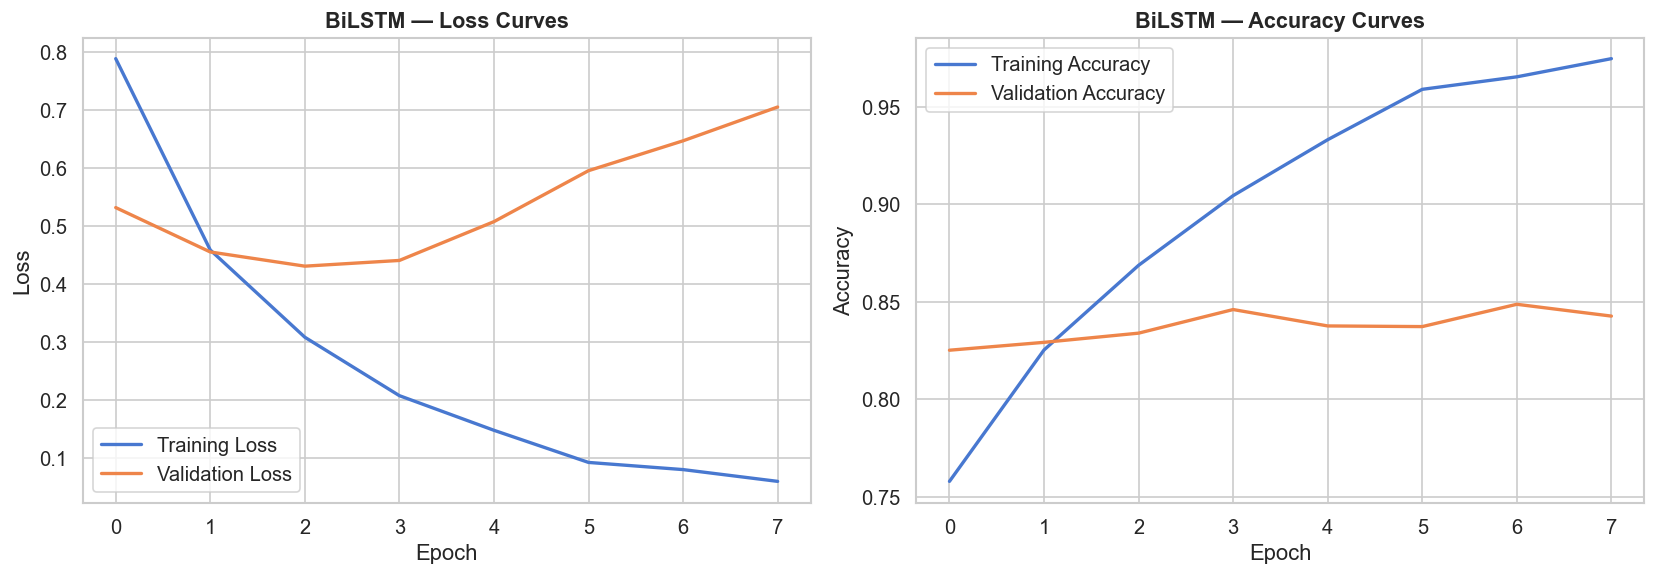

In [24]:
# ============================================================
# 8.4 BiLSTM — Training curves
# ============================================================
# Training curves show how loss and accuracy evolve over epochs.
# What to look for:
# - Training and validation curves should be CLOSE — large gap = overfitting
# - Both should decrease (loss) or increase (accuracy) and then plateau
# - The point where validation loss starts increasing while training loss
#   continues decreasing is where overfitting begins (early stopping catches this)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_lstm.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('BiLSTM — Loss Curves', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_lstm.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('BiLSTM — Accuracy Curves', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_bilstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ============================================================
# 8.5 BiLSTM — Evaluation on test set
# ============================================================
# Get predictions from the trained BiLSTM.
# predict() returns probabilities for each class (shape: [n_samples, 3]).
# argmax picks the class with highest probability as the final prediction.

y_prob_lstm = bilstm_model.predict(X_test_pad, verbose=0)
y_pred_lstm = np.argmax(y_prob_lstm, axis=1)

print("BiLSTM — Test Set Results")
print("=" * 60)
print(f"Macro F1-score: {f1_score(y_test, y_pred_lstm, average='macro'):.4f}")
print(f"Weighted F1:    {f1_score(y_test, y_pred_lstm, average='weighted'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=list(label_map.values())))

BiLSTM — Test Set Results
Macro F1-score: 0.6950
Weighted F1:    0.8515

Classification Report:
              precision    recall  f1-score   support

 Hate Speech       0.25      0.63      0.36       286
   Offensive       0.95      0.84      0.89      3838
     Neither       0.82      0.85      0.84       832

    accuracy                           0.83      4956
   macro avg       0.67      0.77      0.69      4956
weighted avg       0.89      0.83      0.85      4956



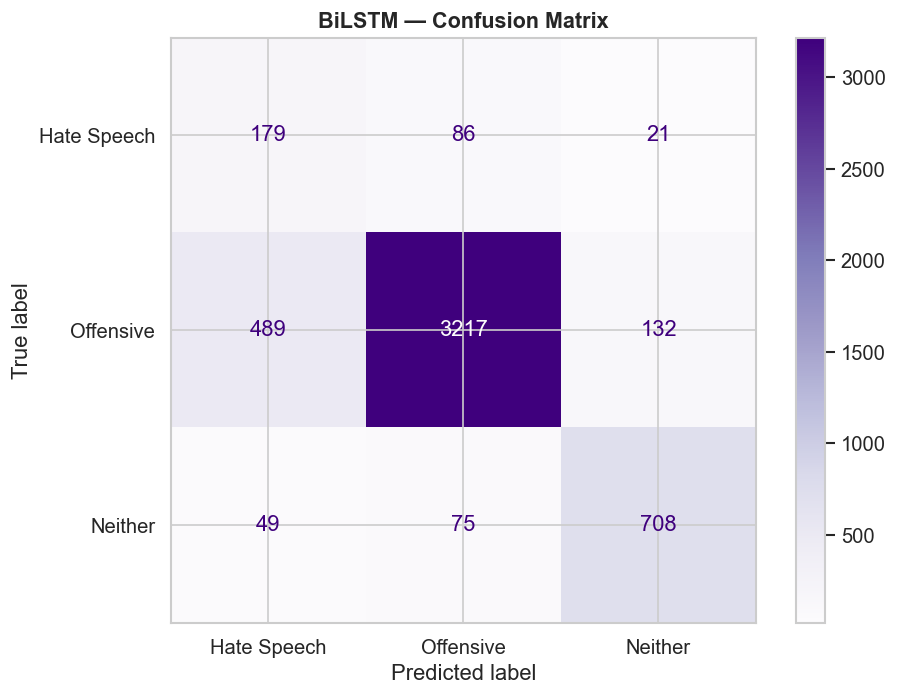

In [26]:
# ============================================================
# 8.6 BiLSTM — Confusion matrix
# ============================================================
# Compare to NB and SVM matrices — the BiLSTM should capture sequential
# patterns that bag-of-words approaches miss, potentially reducing confusion
# between Hate Speech and Offensive classes.

fig, ax = plt.subplots(figsize=(8, 6))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
disp = ConfusionMatrixDisplay(cm_lstm, display_labels=list(label_map.values()))
disp.plot(ax=ax, cmap='Purples', values_format='d')
ax.set_title('BiLSTM — Confusion Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_bilstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Deep Learning — Fine-tuned DistilBERT (Transformer)

DistilBERT (Sanh et al., 2019) is a distilled version of BERT that retains 97% of BERT's 
language understanding while being 60% faster and 40% smaller. It uses the **Transformer 
architecture** with self-attention mechanisms to capture contextual relationships between words.

**Fine-tuning strategy:**
- Use pre-trained `distilbert-base-uncased` weights
- Add a classification head for 3 classes
- Use a low learning rate (2e-5) to preserve pre-trained knowledge
- Apply linear warmup + weight decay (AdamW optimiser)
- Train for 3 epochs (standard for fine-tuning)
- Apply class-weighted loss to handle imbalance

This represents **transfer learning** — leveraging knowledge from pre-training on a massive 
corpus (BookCorpus + English Wikipedia) and adapting it to our specific hate speech detection task.

**Implementation note:** DistilBERT is implemented in PyTorch via HuggingFace Transformers, 
while the BiLSTM uses TensorFlow/Keras. This demonstrates flexibility across both major 
deep learning frameworks.

In [27]:
# ============================================================
# 9.1 Tokenise data for DistilBERT & create PyTorch Dataset
# ============================================================
# DistilBERT has its OWN tokenizer (WordPiece) that splits words differently from
# our NLTK-based pipeline. It uses subword tokens: "unhappiness" -> ["un", "##happiness"]
# This means we feed DistilBERT the ORIGINAL cleaned text — it handles tokenisation internally.
#
# We create a custom PyTorch Dataset class that:
# 1. Tokenises each tweet using the DistilBERT tokenizer
# 2. Pads/truncates to 128 tokens
# 3. Returns input_ids (token integers), attention_mask (1=real token, 0=padding), and label

MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN_BERT = 128

bert_tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

class HateSpeechDataset(TorchDataset):
    """
    Custom PyTorch Dataset for hate speech classification with DistilBERT.
    Handles tokenisation, padding, and tensor conversion for each sample.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.values if hasattr(texts, 'values') else texts
        self.labels = labels.values if hasattr(labels, 'values') else labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # DistilBERT tokenizer adds special tokens: [CLS] at start, [SEP] at end
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Create PyTorch datasets and data loaders
train_dataset_bert = HateSpeechDataset(X_train, y_train, bert_tokenizer, MAX_LEN_BERT)
test_dataset_bert = HateSpeechDataset(X_test, y_test, bert_tokenizer, MAX_LEN_BERT)

# DataLoader handles batching, shuffling, and parallel data loading
BATCH_SIZE_BERT = 16  # Smaller batch size — DistilBERT uses more memory per sample

train_loader = DataLoader(train_dataset_bert, batch_size=BATCH_SIZE_BERT, shuffle=True)
test_loader = DataLoader(test_dataset_bert, batch_size=BATCH_SIZE_BERT, shuffle=False)

print(f"Training samples: {len(train_dataset_bert):,}")
print(f"Test samples: {len(test_dataset_bert):,}")
print(f"Batch size: {BATCH_SIZE_BERT}")
print(f"Training batches: {len(train_loader)}")

Training samples: 19,824
Test samples: 4,956
Batch size: 16
Training batches: 1239


In [28]:
# ============================================================
# 9.2 Load pre-trained DistilBERT and configure training
# ============================================================
# Transfer learning: start with a model pre-trained on Wikipedia + BookCorpus
# (millions of sentences), then fine-tune it on our specific hate speech data.
# The pre-trained weights already "understand" English — we just teach it
# to distinguish hate speech vs offensive vs neither.
#
# Training setup:
# - AdamW optimiser: Adam with weight decay (L2 regularisation) to prevent overfitting
# - Learning rate 2e-5: very small because we're FINE-TUNING, not training from scratch
#   (large learning rates would destroy the pre-trained knowledge)
# - Linear warmup: gradually increases LR from 0 to 2e-5 over the first 10% of steps
#   to stabilise early training
# - Class-weighted loss: same principle as BiLSTM — penalises more for minority class errors

bert_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3  # our 3 classes: Hate Speech, Offensive, Neither
)
bert_model.to(device)

NUM_EPOCHS_BERT = 3  # 3 epochs is standard for transformer fine-tuning
num_train_steps = len(train_loader) * NUM_EPOCHS_BERT
num_warmup_steps = num_train_steps // 10  # warm up for 10% of training

optimizer_bert = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_train_steps
)

# Weighted cross-entropy loss: minority classes get higher loss weights
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train.values)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float).to(device)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"Model parameters: {sum(p.numel() for p in bert_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in bert_model.parameters() if p.requires_grad):,}")
print(f"Total training steps: {num_train_steps}")
print(f"Warmup steps: {num_warmup_steps}")
print(f"Device: {device}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 66,955,779
Trainable parameters: 66,955,779
Total training steps: 3717
Warmup steps: 371
Device: cpu


In [29]:
# ============================================================
# 9.3 Fine-tune DistilBERT
# ============================================================
# PyTorch requires a manual training loop (unlike Keras' model.fit()).
# Each epoch:
#   1. Training phase: forward pass -> compute loss -> backward pass -> update weights
#   2. Validation phase: forward pass only (no gradient updates) -> measure performance
#
# Gradient clipping (max_norm=1.0) prevents exploding gradients which can destabilise
# transformer training. This caps the gradient magnitude so weight updates stay controlled.
#
# NOTE: On CPU this takes 1-2 hours. Use Google Colab with GPU for faster training.

history_bert = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS_BERT):
    # --- Training phase ---
    bert_model.train()  # Enable dropout and batch norm (training mode)
    total_train_loss = 0
    correct_train = 0
    total_train = 0
    
    for batch_idx, batch in enumerate(train_loader):
        # Move data to device (CPU or GPU)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        # Forward pass: feed tokens through DistilBERT to get class logits
        optimizer_bert.zero_grad()  # Clear gradients from previous step
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)  # Compute weighted cross-entropy loss
        
        # Backward pass: compute gradients and update model weights
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
        optimizer_bert.step()
        scheduler.step()  # Update learning rate according to warmup schedule
        
        # Track metrics
        total_train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}/{NUM_EPOCHS_BERT} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_acc = correct_train / total_train
    
    # --- Validation phase ---
    bert_model.eval()  # Disable dropout (evaluation mode)
    total_val_loss = 0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():  # No gradient computation needed for evaluation
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            
            total_val_loss += loss.item()
            
            preds = torch.argmax(outputs.logits, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
    
    avg_val_loss = total_val_loss / len(test_loader)
    val_acc = correct_val / total_val
    
    history_bert['train_loss'].append(avg_train_loss)
    history_bert['val_loss'].append(avg_val_loss)
    history_bert['train_acc'].append(train_acc)
    history_bert['val_acc'].append(val_acc)
    
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS_BERT}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

print("\nDistilBERT fine-tuning complete.")

  Epoch 1/3 | Batch 100/1239 | Loss: 1.2022
  Epoch 1/3 | Batch 200/1239 | Loss: 0.8278
  Epoch 1/3 | Batch 300/1239 | Loss: 0.9753
  Epoch 1/3 | Batch 400/1239 | Loss: 0.2781
  Epoch 1/3 | Batch 500/1239 | Loss: 0.2543
  Epoch 1/3 | Batch 600/1239 | Loss: 1.2440
  Epoch 1/3 | Batch 700/1239 | Loss: 0.2935
  Epoch 1/3 | Batch 800/1239 | Loss: 0.1997
  Epoch 1/3 | Batch 900/1239 | Loss: 0.1493
  Epoch 1/3 | Batch 1000/1239 | Loss: 0.1682
  Epoch 1/3 | Batch 1100/1239 | Loss: 0.2335
  Epoch 1/3 | Batch 1200/1239 | Loss: 0.1981

Epoch 1/3
  Train Loss: 0.6442 | Train Acc: 0.8331
  Val Loss:   0.4810 | Val Acc:   0.8785
--------------------------------------------------
  Epoch 2/3 | Batch 100/1239 | Loss: 1.3676
  Epoch 2/3 | Batch 200/1239 | Loss: 0.2615
  Epoch 2/3 | Batch 300/1239 | Loss: 0.5279
  Epoch 2/3 | Batch 400/1239 | Loss: 0.1744
  Epoch 2/3 | Batch 500/1239 | Loss: 0.3096
  Epoch 2/3 | Batch 600/1239 | Loss: 0.6074
  Epoch 2/3 | Batch 700/1239 | Loss: 0.4713
  Epoch 2/3 | Bat

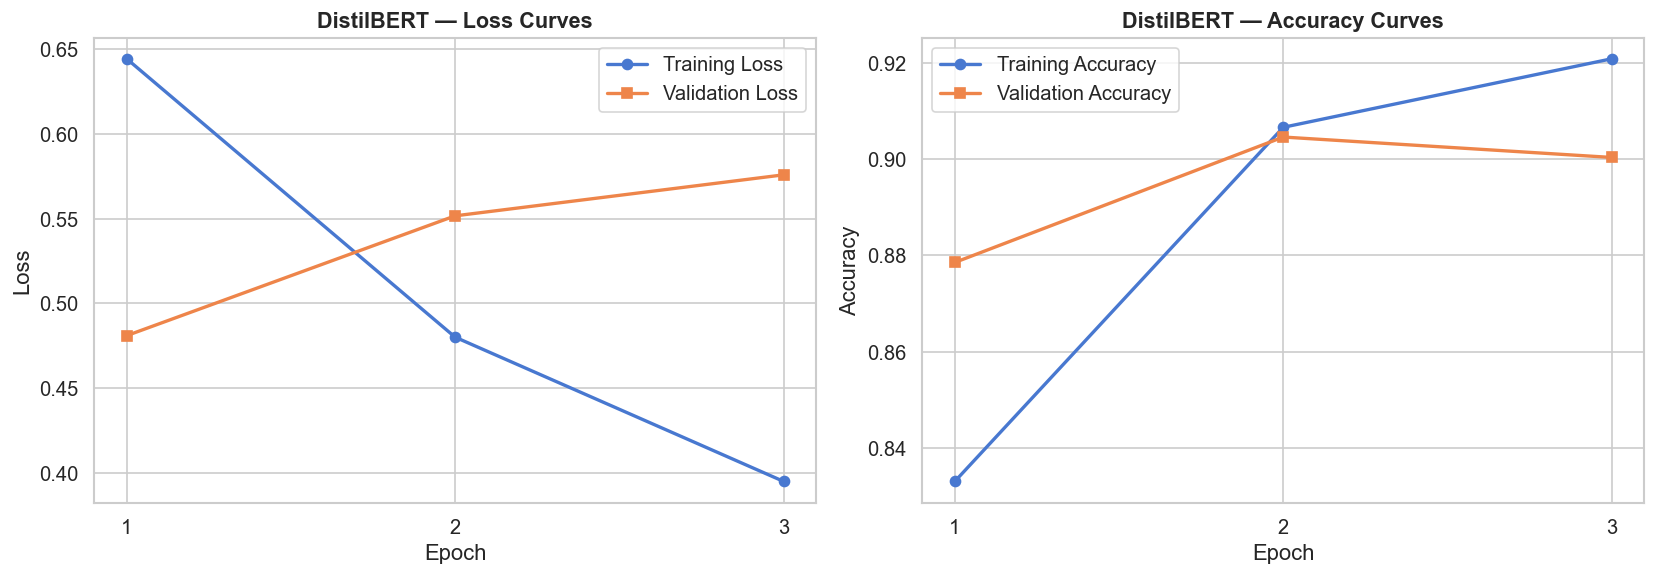

In [30]:
# ============================================================
# 9.4 DistilBERT — Training curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS_BERT + 1)

# Loss curves
axes[0].plot(epochs_range, history_bert['train_loss'], label='Training Loss', linewidth=2, marker='o')
axes[0].plot(epochs_range, history_bert['val_loss'], label='Validation Loss', linewidth=2, marker='s')
axes[0].set_title('DistilBERT — Loss Curves', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_xticks(list(epochs_range))

# Accuracy curves
axes[1].plot(epochs_range, history_bert['train_acc'], label='Training Accuracy', linewidth=2, marker='o')
axes[1].plot(epochs_range, history_bert['val_acc'], label='Validation Accuracy', linewidth=2, marker='s')
axes[1].set_title('DistilBERT — Accuracy Curves', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_xticks(list(epochs_range))

plt.tight_layout()
plt.savefig('fig_bert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# ============================================================
# 9.5 DistilBERT — Evaluation on test set
# ============================================================
# Run the fine-tuned model on the test set to get predictions and probabilities.
# Logits (raw model outputs) are converted to probabilities via softmax,
# then argmax picks the class with the highest probability.

bert_model.eval()  # Ensure evaluation mode (dropout off)
all_preds = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        
        # Softmax converts logits to probabilities that sum to 1.0 per sample
        probs = torch.nn.functional.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

y_pred_bert = np.array(all_preds)
y_prob_bert = np.array(all_probs)

print("DistilBERT — Test Set Results")
print("=" * 60)
print(f"Macro F1-score: {f1_score(y_test, y_pred_bert, average='macro'):.4f}")
print(f"Weighted F1:    {f1_score(y_test, y_pred_bert, average='weighted'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_bert, target_names=list(label_map.values())))

DistilBERT — Test Set Results
Macro F1-score: 0.7644
Weighted F1:    0.9038

Classification Report:
              precision    recall  f1-score   support

 Hate Speech       0.42      0.52      0.47       286
   Offensive       0.95      0.93      0.94      3838
     Neither       0.87      0.90      0.89       832

    accuracy                           0.90      4956
   macro avg       0.75      0.78      0.76      4956
weighted avg       0.91      0.90      0.90      4956



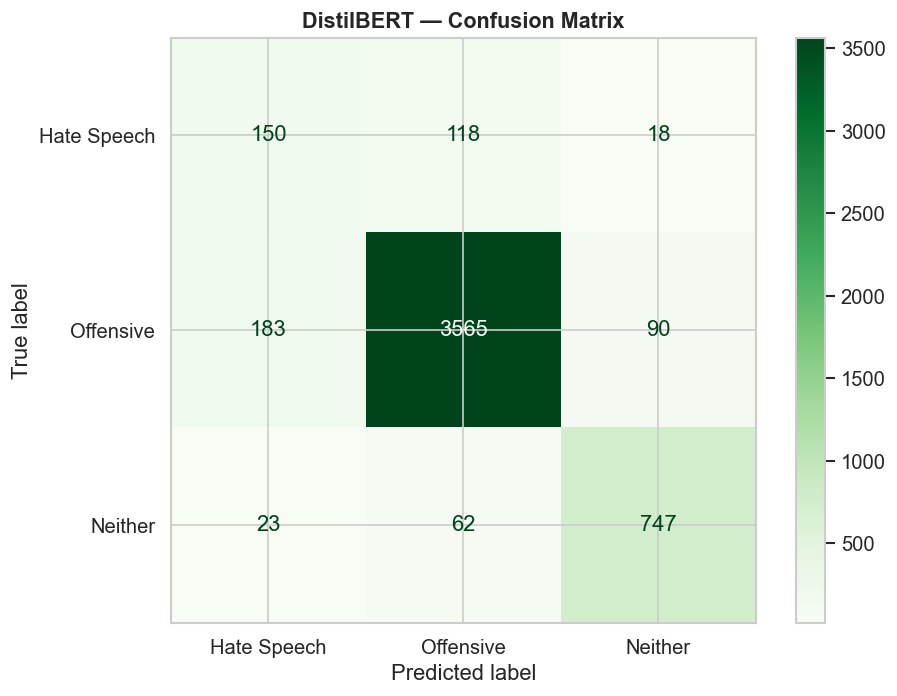

In [32]:
# ============================================================
# 9.6 DistilBERT — Confusion matrix
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))
cm_bert = confusion_matrix(y_test, y_pred_bert)
disp = ConfusionMatrixDisplay(cm_bert, display_labels=list(label_map.values()))
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title('DistilBERT — Confusion Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Model Comparison & Final Evaluation

This section provides a comprehensive comparison across all four models using multiple metrics
and visualisations. We evaluate using:

1. **Macro F1-score** — Treats all classes equally (critical for imbalanced data)
2. **Weighted F1-score** — Accounts for class support
3. **ROC-AUC (One-vs-Rest)** — Measures discriminative ability across thresholds
4. **PR-AUC (Average Precision)** — Particularly informative for imbalanced classes

We also present ROC curves, precision-recall curves, and a consolidated results table.

In [33]:
# ============================================================
# 10.1 Consolidated results table
# ============================================================
# Compare all models side by side using four metrics:
# - Macro F1: treats all classes equally — our PRIMARY metric for imbalanced data
# - Weighted F1: weights each class by its support (sample count) — reflects overall performance
# - ROC-AUC (One-vs-Rest): measures how well the model discriminates between classes
#   across all possible classification thresholds (1.0 = perfect, 0.5 = random)
# - PR-AUC (Average Precision): focuses on the precision-recall trade-off,
#   especially informative for rare classes like Hate Speech

# Binarise labels for multi-class ROC/PR computation (one-hot encoding)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

results = {}

model_preds = {
    'Baseline (Majority)': (y_pred_base, None),
    'Naive Bayes (CNB)': (y_pred_nb, y_prob_nb),
    'SVM (Linear)': (y_pred_svm, y_prob_svm),
    'BiLSTM': (y_pred_lstm, y_prob_lstm),
    'DistilBERT': (y_pred_bert, y_prob_bert)
}

for name, (y_pred, y_prob) in model_preds.items():
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    
    if y_prob is not None:
        roc_auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
        pr_auc = average_precision_score(y_test_bin, y_prob, average='macro')
    else:
        roc_auc = None
        pr_auc = None
    
    results[name] = {
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }

results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("=" * 70)
print("FINAL MODEL COMPARISON — ALL METRICS")
print("=" * 70)
print(results_df.to_string())
print("\nBest model by Macro F1:", results_df['Macro F1'].idxmax())

FINAL MODEL COMPARISON — ALL METRICS
                     Macro F1  Weighted F1  ROC-AUC  PR-AUC
Baseline (Majority)    0.2910       0.6760      NaN     NaN
Naive Bayes (CNB)      0.6224       0.8038   0.8414  0.6517
SVM (Linear)           0.6785       0.8623   0.8743  0.6831
BiLSTM                 0.6950       0.8515   0.9143  0.7331
DistilBERT             0.7644       0.9038   0.9410  0.7829

Best model by Macro F1: DistilBERT


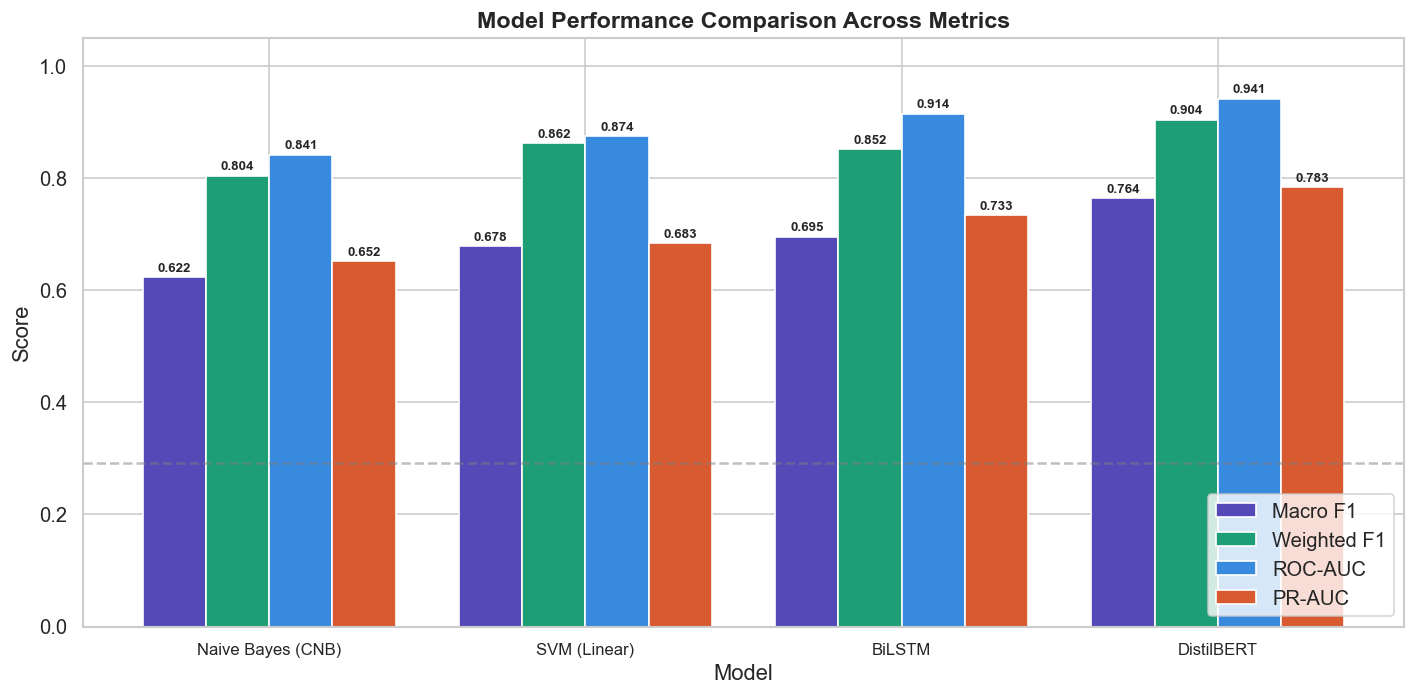

In [34]:
# ============================================================
# 10.2 Model comparison bar chart
# ============================================================
# Grouped bar chart comparing all 4 models across all 4 metrics.
# The baseline is shown as a dashed horizontal line for reference.
# This single visualisation makes it easy to see which model wins overall
# and whether the improvement from simple to complex models is worthwhile.

fig, ax = plt.subplots(figsize=(12, 6))

compare_df = results_df.drop('Baseline (Majority)')
x = np.arange(len(compare_df))
width = 0.2

metrics = ['Macro F1', 'Weighted F1', 'ROC-AUC', 'PR-AUC']
metric_colours = ['#534AB7', '#1D9E75', '#378ADD', '#D85A30']

for i, (metric, colour) in enumerate(zip(metrics, metric_colours)):
    values = compare_df[metric].values
    bars = ax.bar(x + i * width, values, width, label=metric, color=colour, edgecolor='white')
    for bar, val in zip(bars, values):
        if pd.notna(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison Across Metrics', fontweight='bold', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(compare_df.index, fontsize=10)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)

# Dashed line showing the baseline Macro F1 — everything above this line is useful
ax.axhline(y=results_df.loc['Baseline (Majority)', 'Macro F1'], color='gray',
           linestyle='--', alpha=0.5, label='Baseline')

plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

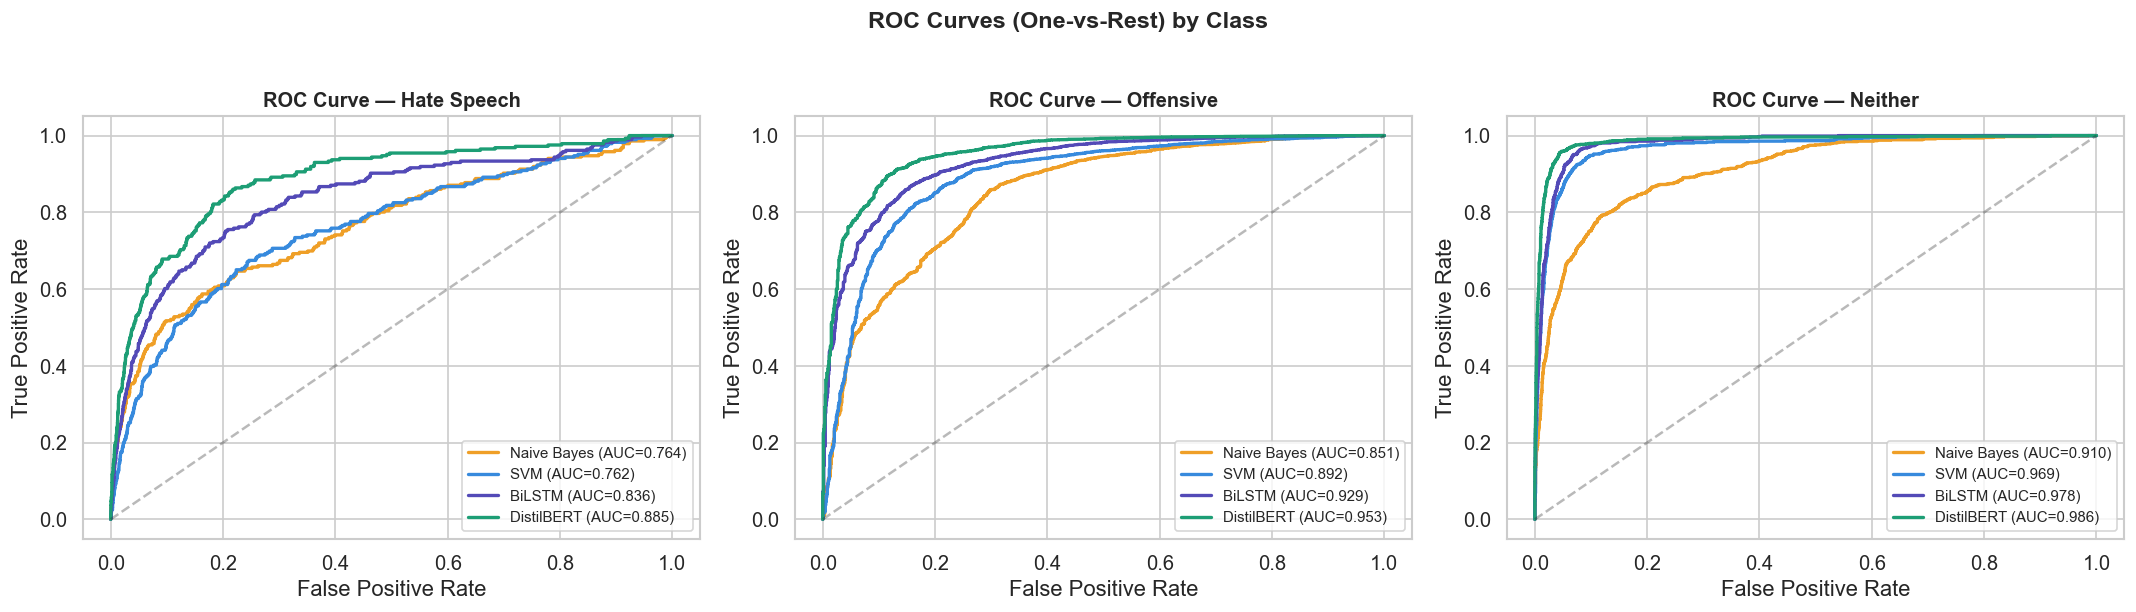

In [35]:
# ============================================================
# 10.3 ROC curves (One-vs-Rest) for all models
# ============================================================
# ROC (Receiver Operating Characteristic) curves plot True Positive Rate vs
# False Positive Rate at different classification thresholds.
# - Curve closer to top-left corner = better model
# - AUC (Area Under Curve) summarises performance: 1.0 = perfect, 0.5 = random
# We plot separate curves for each class to see which classes each model handles best.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_for_roc = {
    'Naive Bayes': y_prob_nb,
    'SVM': y_prob_svm,
    'BiLSTM': y_prob_lstm,
    'DistilBERT': y_prob_bert
}

model_colours = ['#EF9F27', '#378ADD', '#534AB7', '#1D9E75']

for class_idx, class_name in label_map.items():
    ax = axes[class_idx]
    
    for (model_name, y_prob), colour in zip(models_for_roc.items(), model_colours):
        fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], y_prob[:, class_idx])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc_val:.3f})',
                linewidth=2, color=colour)
    
    # Diagonal dashed line = random classifier (AUC=0.5)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f'ROC Curve — {class_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)

plt.suptitle('ROC Curves (One-vs-Rest) by Class', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

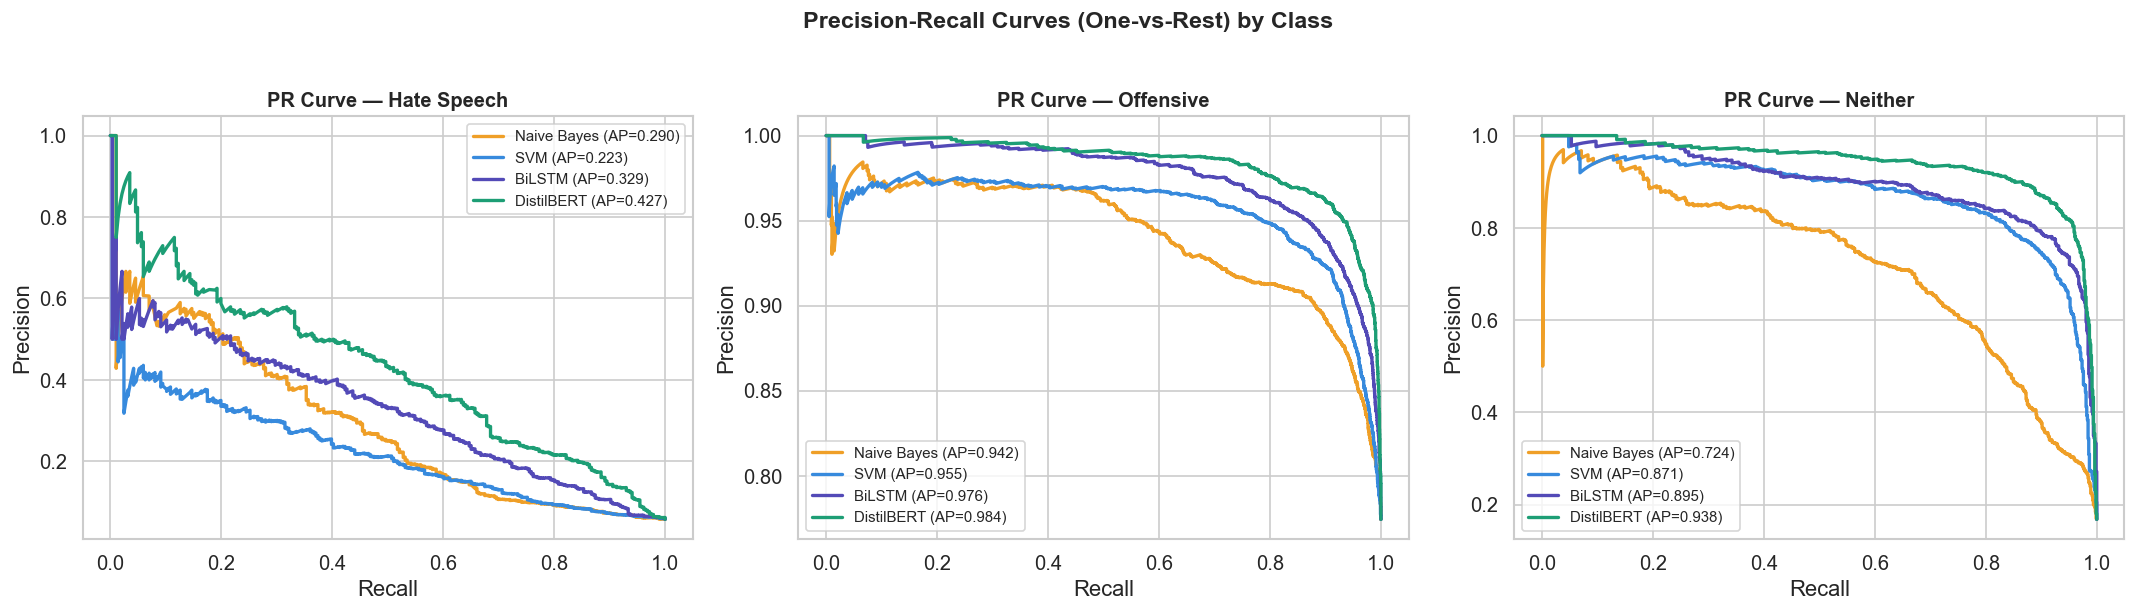

In [36]:
# ============================================================
# 10.4 Precision-Recall curves (One-vs-Rest)
# ============================================================
# PR curves are more informative than ROC for imbalanced datasets because
# they focus on the minority class performance. They plot Precision vs Recall:
# - Precision: of all tweets predicted as class X, how many actually are? (quality)
# - Recall: of all actual class X tweets, how many did we find? (completeness)
# AP (Average Precision) summarises the curve — higher is better.
# The Hate Speech PR curve is the most important since it's the rarest class.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for class_idx, class_name in label_map.items():
    ax = axes[class_idx]
    
    for (model_name, y_prob), colour in zip(models_for_roc.items(), model_colours):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, class_idx], y_prob[:, class_idx])
        ap = average_precision_score(y_test_bin[:, class_idx], y_prob[:, class_idx])
        ax.plot(recall, precision, label=f'{model_name} (AP={ap:.3f})',
                linewidth=2, color=colour)
    
    ax.set_title(f'PR Curve — {class_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=9)

plt.suptitle('Precision-Recall Curves (One-vs-Rest) by Class', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

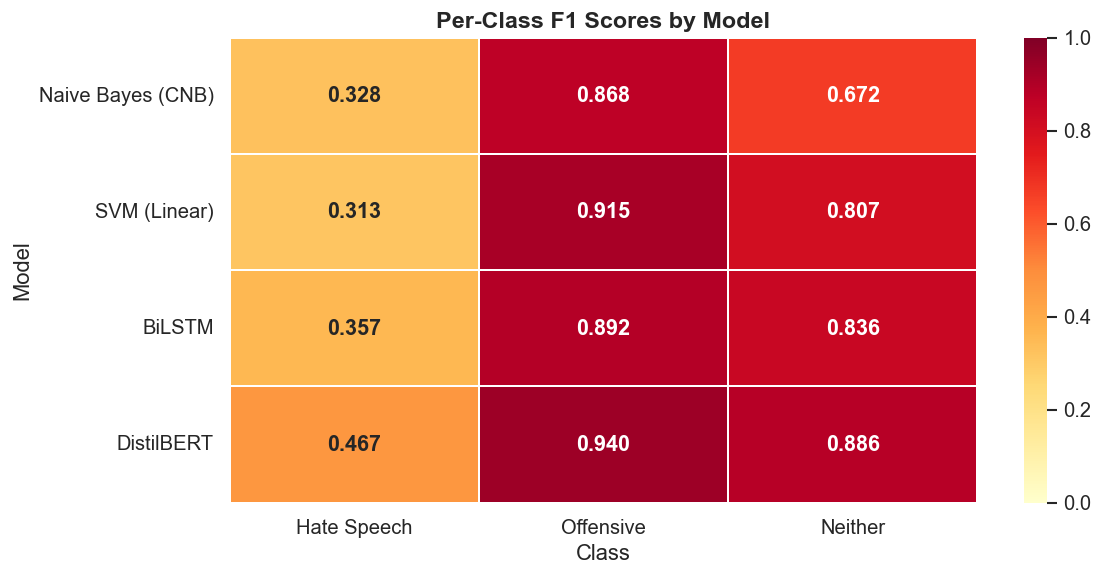

In [37]:
# ============================================================
# 10.5 Heatmap of per-class F1 scores
# ============================================================
# A heatmap gives a quick visual summary: which model performs best on which class?
# Darker colours = higher F1 scores. This makes it easy to spot that all models
# struggle most with Hate Speech (the minority class) and perform best on Offensive.

per_class_f1 = {}
for name, (y_pred, _) in model_preds.items():
    if name == 'Baseline (Majority)':
        continue
    report = classification_report(y_test, y_pred, target_names=list(label_map.values()), output_dict=True)
    per_class_f1[name] = {cls: report[cls]['f1-score'] for cls in label_map.values()}

f1_heatmap_df = pd.DataFrame(per_class_f1).T.round(4)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(f1_heatmap_df, annot=True, fmt='.3f', cmap='YlOrRd', 
            linewidths=1, linecolor='white', ax=ax, vmin=0, vmax=1,
            annot_kws={'fontsize': 13, 'fontweight': 'bold'})
ax.set_title('Per-Class F1 Scores by Model', fontweight='bold', fontsize=14)
ax.set_ylabel('Model')
ax.set_xlabel('Class')

plt.tight_layout()
plt.savefig('fig_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

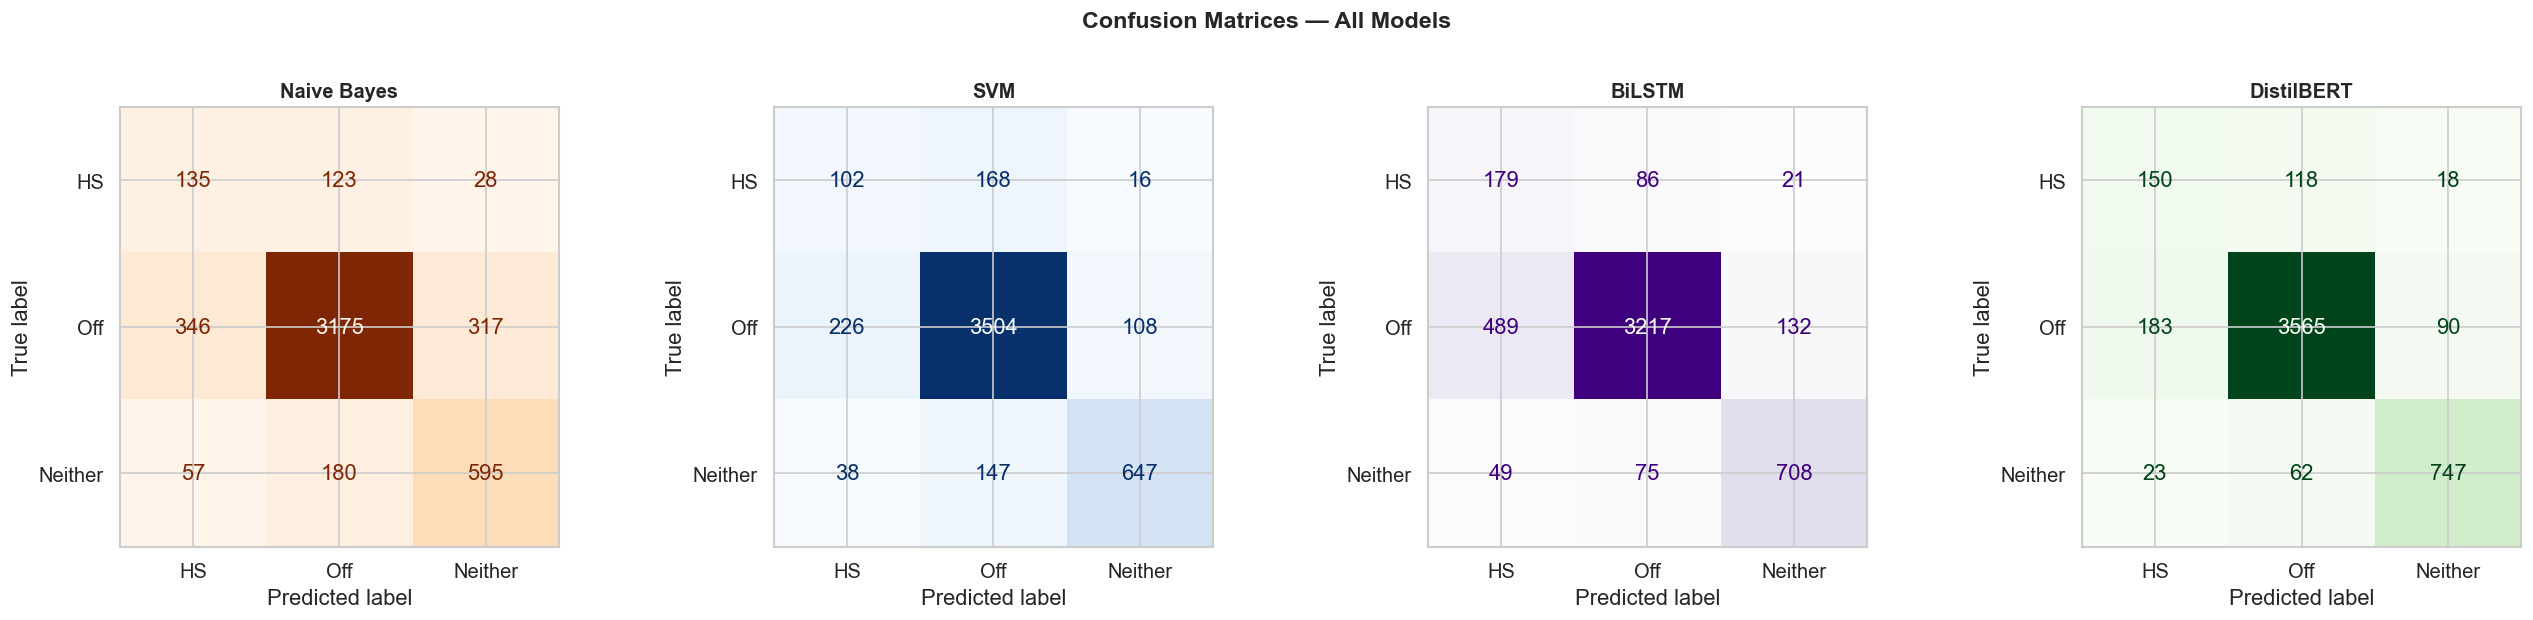

In [38]:
# ============================================================
# 10.6 All confusion matrices side by side
# ============================================================
# Placing all four confusion matrices together makes it easy to compare
# where each model makes mistakes. Look for:
# - How many Hate Speech tweets get misclassified as Offensive (the biggest challenge)
# - Whether more complex models reduce this specific type of error
# - The Neither class should be relatively well-classified by all models

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

cms = [
    ('Naive Bayes', cm_nb, 'Oranges'),
    ('SVM', cm_svm, 'Blues'),
    ('BiLSTM', cm_lstm, 'Purples'),
    ('DistilBERT', cm_bert, 'Greens')
]

for ax, (name, cm, cmap) in zip(axes, cms):
    disp = ConfusionMatrixDisplay(cm, display_labels=['HS', 'Off', 'Neither'])
    disp.plot(ax=ax, cmap=cmap, values_format='d', colorbar=False)
    ax.set_title(name, fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrices — All Models', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Conclusion

This notebook implemented and compared four machine learning models for hate speech detection
on the Davidson et al. (2017) dataset:

**Traditional ML:**
- Complement Naive Bayes with TF-IDF features and SMOTE oversampling
- Linear SVM with TF-IDF features, class balancing, and hyperparameter tuning

**Deep Learning:**
- Bidirectional LSTM with learned embeddings, class weights, and early stopping
- Fine-tuned DistilBERT transformer with linear warmup and weight decay

**Key findings** are documented in the accompanying report. All figures generated in this
notebook are saved as PNG files for inclusion in the written report.

---

### Figures Generated

| Figure | Filename |
|--------|----------|
| Class Distribution | `fig_class_distribution.png` |
| Text Length Analysis | `fig_text_length_analysis.png` |
| Word Clouds | `fig_word_clouds.png` |
| N-gram Analysis | `fig_ngram_analysis.png` |
| NB Confusion Matrix | `fig_nb_confusion_matrix.png` |
| SVM Confusion Matrix | `fig_svm_confusion_matrix.png` |
| BiLSTM Training Curves | `fig_bilstm_training_curves.png` |
| BiLSTM Confusion Matrix | `fig_bilstm_confusion_matrix.png` |
| BERT Training Curves | `fig_bert_training_curves.png` |
| BERT Confusion Matrix | `fig_bert_confusion_matrix.png` |
| Model Comparison | `fig_model_comparison.png` |
| ROC Curves | `fig_roc_curves.png` |
| PR Curves | `fig_pr_curves.png` |
| F1 Heatmap | `fig_f1_heatmap.png` |
| All Confusion Matrices | `fig_all_confusion_matrices.png` |

---

**References:**
- Davidson, T., Warmsley, D., Macy, M. & Weber, I. (2017). Automated Hate Speech Detection and the Problem of Offensive Language. *ICWSM*.
- Sanh, V., Debut, L., Chaumond, J. & Wolf, T. (2019). DistilBERT, a distilled version of BERT. *arXiv:1910.01108*.
- Rennie, J.D.M., Shih, L., Teevan, J. & Karger, D.R. (2003). Tackling the Poor Assumptions of Naive Bayes Text Classifiers. *ICML*.
- Joachims, T. (1998). Text categorization with Support Vector Machines. *ECML*.
